In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/System-Threat-Forecaster/sample_submission.csv
/kaggle/input/System-Threat-Forecaster/train.csv
/kaggle/input/System-Threat-Forecaster/test.csv


<u><h1 style="text-align:center;" >Description</h1></u>
<h4>The data contains some properties of systems to predict the probability of a system getting infected by different families of malware. The data comes from telemetry reports collected by antivirus software containing the target that whether the system infected (1) or not infected(0). Early detection of the malware infection can help prevent security breaches.</h4>

# Importing Libraries

In [3]:
import pandas as pd
import numpy as np
import warnings
from sklearn.preprocessing import StandardScaler, MinMaxScaler,MaxAbsScaler,OrdinalEncoder
from sklearn.impute import SimpleImputer,KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier 
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from scipy.stats import uniform
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree

In [4]:
warnings.filterwarnings(action='ignore')

# Load Data

In [5]:
train_data = pd.read_csv('/kaggle/input/System-Threat-Forecaster/train.csv')
test_data = pd.read_csv('/kaggle/input/System-Threat-Forecaster/test.csv')

<u><h1 style="text-align:center;" >Exploratory Data Analysis</h1></u>

In [6]:
print(f"Shape of training data{train_data.shape}")
print(f"Shape of test data {test_data.shape}")

Shape of training data(100000, 76)
Shape of test data (10000, 75)


In [7]:
train_data.head(3)

,MachineID,ProductName,EngineVersion,AppVersion,SignatureVersion,IsBetaUser,RealTimeProtectionState,IsPassiveModeEnabled,AntivirusConfigID,NumAntivirusProductsInstalled,...,IsSecureBootEnabled,IsVirtualDevice,IsTouchEnabled,IsPenCapable,IsAlwaysOnAlwaysConnectedCapable,IsGamer,RegionIdentifier,DateAS,DateOS,target
0,f541bae429089117c4aac39c90dd3416,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1003.0,0,7.0,0,53447.0,1.0,...,0,0.0,1,0,1.0,0.0,6.0,2018-09-10 10:11:00,2018-04-17,0
1,dc2b14d9ce3a0ce4050bb640190f2ca5,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1465.0,0,7.0,0,53447.0,1.0,...,1,0.0,0,0,0.0,0.0,10.0,2018-08-16 00:01:00,2018-08-14,1
2,fd20c5f010e9c5f91ad1c6b3e0da68a0,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1546.0,0,7.0,0,53447.0,1.0,...,0,0.0,0,0,0.0,1.0,6.0,2018-09-20 23:20:00,2018-09-11,1


In [8]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 76 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   MachineID                           100000 non-null  object 
 1   ProductName                         100000 non-null  object 
 2   EngineVersion                       100000 non-null  object 
 3   AppVersion                          100000 non-null  object 
 4   SignatureVersion                    100000 non-null  object 
 5   IsBetaUser                          100000 non-null  int64  
 6   RealTimeProtectionState             99934 non-null   float64
 7   IsPassiveModeEnabled                100000 non-null  int64  
 8   AntivirusConfigID                   99924 non-null   float64
 9   NumAntivirusProductsInstalled       99924 non-null   float64
 10  NumAntivirusProductsEnabled         99924 non-null   float64
 11  HasTpm                     

In [9]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 75 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   MachineID                           10000 non-null  object 
 1   ProductName                         10000 non-null  object 
 2   EngineVersion                       10000 non-null  object 
 3   AppVersion                          10000 non-null  object 
 4   SignatureVersion                    10000 non-null  object 
 5   IsBetaUser                          10000 non-null  int64  
 6   RealTimeProtectionState             9991 non-null   float64
 7   IsPassiveModeEnabled                10000 non-null  int64  
 8   AntivirusConfigID                   9998 non-null   float64
 9   NumAntivirusProductsInstalled       9998 non-null   float64
 10  NumAntivirusProductsEnabled         9998 non-null   float64
 11  HasTpm                              10000 

In [10]:
categorical_columns = train_data.drop('target',axis = 1).select_dtypes(include='object').columns.tolist()
numerical_columns = train_data.drop('target',axis = 1).select_dtypes(include='number').columns.tolist()
print(f"Data contains {len(categorical_columns)} categorical columns and {len(numerical_columns)} numerical columns.")

Data contains 28 categorical columns and 47 numerical columns.


<h2>Distribution of Target Labels</h2>


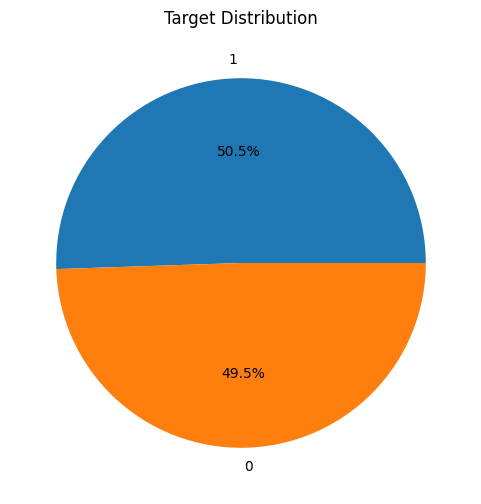

In [11]:
target = train_data['target']
plt.figure(figsize=(6,6))
plt.pie(target.value_counts(),labels = target.value_counts().index,autopct='%1.1f%%')
plt.title('Target Distribution')
plt.show()

<h3>Findings: </h3>
<h5>The pie chart for target Distribution shows that both categories in the target are equally distributed.</h5>

In [12]:
print(f"Number of systems infected : {target.value_counts()[1]} ")
print(f"Number of systems not infected :{target.value_counts()[0]}")

Number of detected malwares mechines is, 50525 
Number of malwares not detected machines is, 49475


<h2>Descriptive Statistics</h2>

In [13]:
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 76)  # Increase output width
test = train_data.describe()
test

,IsBetaUser,RealTimeProtectionState,IsPassiveModeEnabled,AntivirusConfigID,NumAntivirusProductsInstalled,NumAntivirusProductsEnabled,HasTpm,CountryID,CityID,GeoRegionID,LocaleEnglishNameID,OSBuildNumber,OSProductSuite,IsSystemProtected,AutoSampleSubmissionEnabled,SMode,IEVersionID,FirewallEnabled,EnableLUA,OEMNameID,OEMModelID,ProcessorCoreCount,ProcessorManufacturerID,ProcessorModelID,PrimaryDiskCapacityMB,SystemVolumeCapacityMB,HasOpticalDiskDrive,TotalPhysicalRAMMB,PrimaryDisplayDiagonalInches,PrimaryDisplayResolutionHorizontal,PrimaryDisplayResolutionVertical,InternalBatteryNumberOfCharges,OSBuildNumberOnly,OSBuildRevisionOnly,OSInstallLanguageID,OSUILocaleID,IsPortableOS,IsFlightsDisabled,FirmwareManufacturerID,FirmwareVersionID,IsSecureBootEnabled,IsVirtualDevice,IsTouchEnabled,IsPenCapable,IsAlwaysOnAlwaysConnectedCapable,IsGamer,RegionIdentifier,target
count,100000.0,99934.000000,100000.000000,99924.000000,99924.000000,99924.000000,100000.000000,100000.000000,99377.000000,100000.000000,100000.000000,100000.000000,100000.000000,99924.000000,100000.0,99019.000000,99893.000000,99834.000000,99981.000000,99788.000000,99772.000000,99915.000000,99915.000000,99915.000000,9.989000e+04,9.989000e+04,100000.00000,99849.000000,99928.000000,99928.000000,99928.000000,9.948500e+04,100000.000000,100000.000000,99887.000000,100000.000000,100000.000000,99674.0,99624.000000,99666.000000,100000.000000,99980.000000,100000.000000,100000.000000,99866.000000,99441.000000,99441.000000,100000.000000
mean,0.0,6.848430,0.017620,47975.710440,1.326528,1.018264,0.996780,108.078790,81029.938587,169.741630,122.695100,15917.208720,578.403380,0.955326,0.0,0.000505,124.053848,0.980067,0.996569,2209.573265,238780.914154,4.011500,4.530711,2367.693069,5.158619e+05,3.819905e+05,0.08140,6132.087442,16.708674,1552.230416,898.253192,1.118069e+09,15990.596350,986.531360,14.519267,60.030870,0.000520,0.0,401.987613,32942.648044,0.495690,0.003841,0.128470,0.040580,0.058398,0.296668,7.875866,0.505250
std,0.0,1.015166,0.131566,13803.321533,0.520681,0.155291,0.056654,63.062151,48944.027074,89.188929,69.242252,1943.421132,247.240971,0.206588,0.0,0.022466,33.535395,0.139771,0.266669,1300.863891,71708.483379,2.033075,1.288050,837.822392,3.525624e+05,3.246240e+05,0.27345,4813.882548,6.031598,363.438980,213.695880,1.884682e+09,1810.756601,2971.429862,10.142233,44.715508,0.022798,0.0,221.318891,21151.970827,0.499984,0.061855,0.334614,0.197316,0.234496,0.456791,4.562533,0.499975
min,0.0,0.000000,0.000000,39.000000,1.000000,0.000000,0.000000,1.000000,7.000000,1.000000,1.000000,7601.000000,16.000000,0.000000,0.0,0.000000,39.000000,0.000000,0.000000,46.000000,22.000000,1.000000,1.000000,3.000000,1.228800e+04,1.088000e+04,0.00000,512.000000,5.300000,400.000000,300.000000,0.000000e+00,10240.000000,0.000000,1.000000,5.000000,0.000000,0.0,2.000000,121.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.0,7.000000,0.000000,49480.000000,1.000000,1.000000,1.000000,51.000000,36694.000000,89.000000,74.000000,16299.000000,256.000000,1.000000,0.0,0.000000,111.000000,1.000000,1.000000,1443.000000,189586.000000,2.000000,5.000000,1998.000000,2.441980e+05,1.208410e+05,0.00000,4096.000000,13.900000,1366.000000,768.000000,0.000000e+00,16299.000000,167.000000,8.000000,31.000000,0.000000,0.0,142.000000,13020.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
50%,0.0,7.000000,0.000000,53447.000000,1.000000,1.000000,1.000000,97.000000,82373.000000,181.000000,88.000000,16299.000000,768.000000,1.000000,0.0,0.000000,135.000000,1.000000,1.000000,2102.000000,246528.000000,4.000000,5.000000,2503.000000,4.769400e+05,2.567655e+05,0.00000,4096.000000,15.500000,1366.000000,768.000000,0.000000e+00,16299.000000,285.000000,9.000000,34.000000,0.000000,0.0,500.000000,33066.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,1.000000
75%,0.0,7.000000,0.000000,53447.000000,2.000000,1.000000,1.000000,162.000000,122835.000000,267.000000,182

In [14]:
train_data['IsBetaUser'].value_counts()

IsBetaUser
0    100000
Name: count, dtype: int64

In [ ]:
train_data['AutoSampleSubmissionEnabled'].value_counts()

In [15]:
skewness = train_data[numerical_columns].skew()
symmetric_columns = []
right_skewed = []
left_skewed = []
for col, skew_value in skewness.items():
    if abs(skew_value) < 0.5:  
        symmetric_columns.append(col)
    elif skew_value > 0.5:  
        right_skewed.append(col)
    else:  
        left_skewed.append(col)

print("Symmetric Columns:", symmetric_columns)
print("\n\n")
print("Right-Skewed Columns:", right_skewed)
print("\n\n")
print("Left-Skewed Columns:", left_skewed)

Symmetric Columns: ['IsBetaUser', 'CountryID', 'CityID', 'GeoRegionID', 'AutoSampleSubmissionEnabled', 'IsFlightsDisabled', 'FirmwareManufacturerID', 'FirmwareVersionID', 'IsSecureBootEnabled', 'RegionIdentifier']



Right-Skewed Columns: ['IsPassiveModeEnabled', 'NumAntivirusProductsInstalled', 'NumAntivirusProductsEnabled', 'LocaleEnglishNameID', 'SMode', 'IEVersionID', 'EnableLUA', 'OEMNameID', 'ProcessorCoreCount', 'PrimaryDiskCapacityMB', 'SystemVolumeCapacityMB', 'HasOpticalDiskDrive', 'TotalPhysicalRAMMB', 'PrimaryDisplayDiagonalInches', 'PrimaryDisplayResolutionHorizontal', 'PrimaryDisplayResolutionVertical', 'InternalBatteryNumberOfCharges', 'OSBuildRevisionOnly', 'OSInstallLanguageID', 'OSUILocaleID', 'IsPortableOS', 'IsVirtualDevice', 'IsTouchEnabled', 'IsPenCapable', 'IsAlwaysOnAlwaysConnectedCapable', 'IsGamer']



Left-Skewed Columns: ['RealTimeProtectionState', 'AntivirusConfigID', 'HasTpm', 'OSBuildNumber', 'OSProductSuite', 'IsSystemProtected', 'FirewallEnabled', 'OEMM

<h2>Identifying the Reduntant Features</h2>
<h4>1. High Cardinality Features</h4>

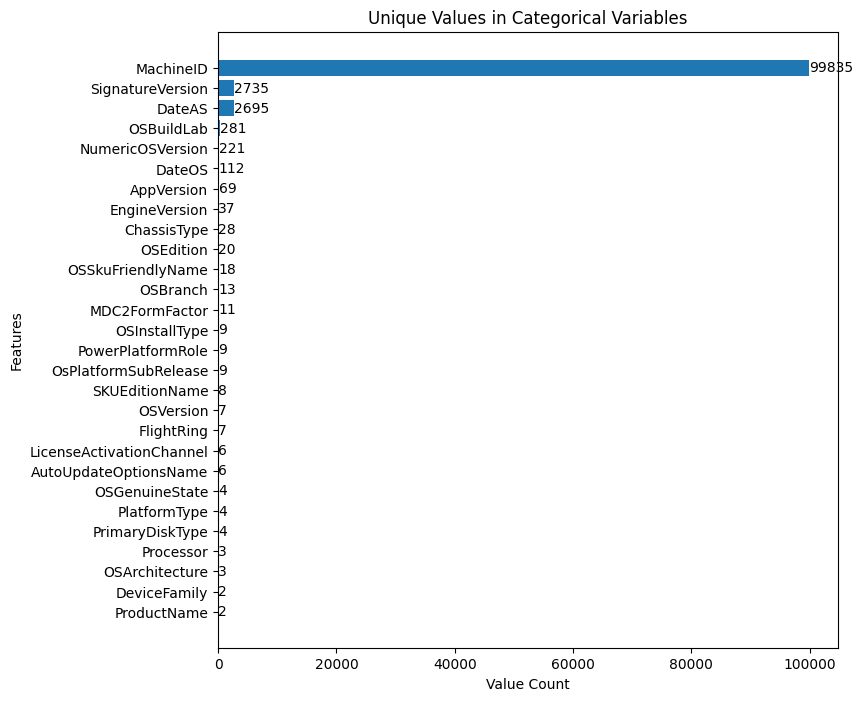

In [16]:
#plot for unique values for categorical features
plt.figure(figsize=(8,8))
x = train_data[categorical_columns].nunique().sort_values().index 
y = train_data[categorical_columns].nunique().sort_values().values
bars = plt.barh(x,y)
for i, value in enumerate(train_data[categorical_columns].nunique().sort_values().values):
    plt.text(value, i , f'{value}', va='center')
plt.title("Unique Values in Categorical Variables")
plt.xlabel("Value Count")
plt.ylabel("Features")
plt.show()

In [17]:
#Number of unique values 
X = train_data.drop('target',axis = 1)
nunique_df = pd.DataFrame({'feature':X.columns,'unique_count':X.nunique()}).sort_values(by='unique_count',ascending=False).reset_index(drop=True)
print(f"Number of unique values in each features:")
nunique_df

Number of unique values in each features:


,feature,unique_count
0,MachineID,99835
1,SystemVolumeCapacityMB,46188
2,CityID,16047
3,OEMModelID,15952
4,FirmwareVersionID,12299
...,...,...
70,HasTpm,2
71,IsSystemProtected,2
72,IsFlightsDisabled,1
73,AutoSampleSubmissionEnabled,1


In [18]:
nunique_df[nunique_df['unique_count']>0.05*train_data.shape[0]] #5 perc. of dataset

,feature,unique_count
0,MachineID,99835
1,SystemVolumeCapacityMB,46188
2,CityID,16047
3,OEMModelID,15952
4,FirmwareVersionID,12299


<h4>2. Constant or low variance features.</h4>

In [19]:
print("Features containing only one class:")
unique_1_df = nunique_df[nunique_df['unique_count'] == 1]
unique_1_df

Features containing only one class:


,feature,unique_count
72,IsFlightsDisabled,1
73,AutoSampleSubmissionEnabled,1
74,IsBetaUser,1


In [20]:
def drop_single_class_column(df):
    print(f"data shape before dropping columns with single class{df.shape}")
    df.drop(columns=['IsFlightsDisabled','IsBetaUser'],inplace=True)
    print(f"data shape after dropping columns with single class{df.shape}")
    return df
def drop_high_cardinality_column(df):
    print(f"data shape before dropping high cardinality feature{df.shape}")
    df.drop(columns=['MachineID'],inplace=True)
    print(f"data shape after dropping high cardinality feature{df.shape}")
    return df

In [21]:
# Binary columns
print("Features containing only 2 classes:")
unique_2_df = nunique_df[nunique_df['unique_count']==2]
unique_2_df

Features containing only 2 classes:


,feature,unique_count
57,IsPenCapable,2
58,IsTouchEnabled,2
59,IsVirtualDevice,2
60,IsSecureBootEnabled,2
61,IsAlwaysOnAlwaysConnectedCapable,2
62,IsGamer,2
63,HasOpticalDiskDrive,2
64,IsPortableOS,2
65,SMode,2
66,FirewallEnabled,2


In [22]:
#Checking any meaningless values in binary column
for col in unique_2_df['feature']:
    print(f"For the column {col} contains the unique values {train_data[col].unique()}")

For the column IsPenCapable contains the unique values [0 1]
For the column IsTouchEnabled contains the unique values [1 0]
For the column IsVirtualDevice contains the unique values [ 0.  1. nan]
For the column IsSecureBootEnabled contains the unique values [0 1]
For the column IsAlwaysOnAlwaysConnectedCapable contains the unique values [ 1.  0. nan]
For the column IsGamer contains the unique values [ 0.  1. nan]
For the column HasOpticalDiskDrive contains the unique values [0 1]
For the column IsPortableOS contains the unique values [0 1]
For the column SMode contains the unique values [ 0. nan  1.]
For the column FirewallEnabled contains the unique values [ 1.  0. nan]
For the column DeviceFamily contains the unique values ['Windows.Desktop' 'Windows.Server']
For the column IsPassiveModeEnabled contains the unique values [0 1]
For the column ProductName contains the unique values ['win8defender' 'mse']
For the column HasTpm contains the unique values [1 0]
For the column IsSystemProt

In [23]:
# unique values for single valued columns
for col in unique_1_df['feature']:
    print(f"For the column {col} contains the unique values {train_data[col].unique()}")

For the column IsFlightsDisabled contains the unique values [ 0. nan]
For the column AutoSampleSubmissionEnabled contains the unique values [0]
For the column IsBetaUser contains the unique values [0]


<h3>Findings:</h3>
<p>IsFlightsDisabled , AutoSampleSubmissionEnabled, IsBetaUser are having only one unique value in its entire data

MachineID contains 100 percentage unique data</p>

<h3>3. Identifying duplicate rows </h3>

In [24]:
print(f"Number of duplicate rows in the train_data is:{train_data.duplicated().sum()}")
def remove_duplicate(df):
    print(f"Number of duplicate rows in the train_data is:{train_data.duplicated().sum()}")
    df.drop_duplicates(inplace=True)
    print(f"train_data shape after removing duplicate rows {df.shape}")
    return df

Number of duplicate rows in the train_data is:165


<h3>4. Removing highly correlated value</h3>(later part)


<h3>5. Identify the features with high missing values (60perc. in general) </h3>

In [25]:
missing_features = train_data.isna().sum()
missing_features = missing_features[missing_features > 0].sort_values(ascending=False)
print(f"There are {missing_features.shape[0]} columns having null values")
print(f"Total null values are: {missing_features.sum()}")
print(missing_features)

There are 33 columns having null values
Total null values are: 6533
SMode                                 981
CityID                                623
IsGamer                               559
RegionIdentifier                      559
InternalBatteryNumberOfCharges        515
FirmwareManufacturerID                376
FirmwareVersionID                     334
IsFlightsDisabled                     326
OEMModelID                            228
OEMNameID                             212
FirewallEnabled                       166
TotalPhysicalRAMMB                    151
IsAlwaysOnAlwaysConnectedCapable      134
OSInstallLanguageID                   113
SystemVolumeCapacityMB                110
PrimaryDiskCapacityMB                 110
IEVersionID                           107
ProcessorModelID                       85
ProcessorManufacturerID                85
ProcessorCoreCount                     85
AntivirusConfigID                      76
IsSystemProtected                      76
NumAntiv

Findings: There is not much missing values in any features. So no need to remove an entire column based on null value

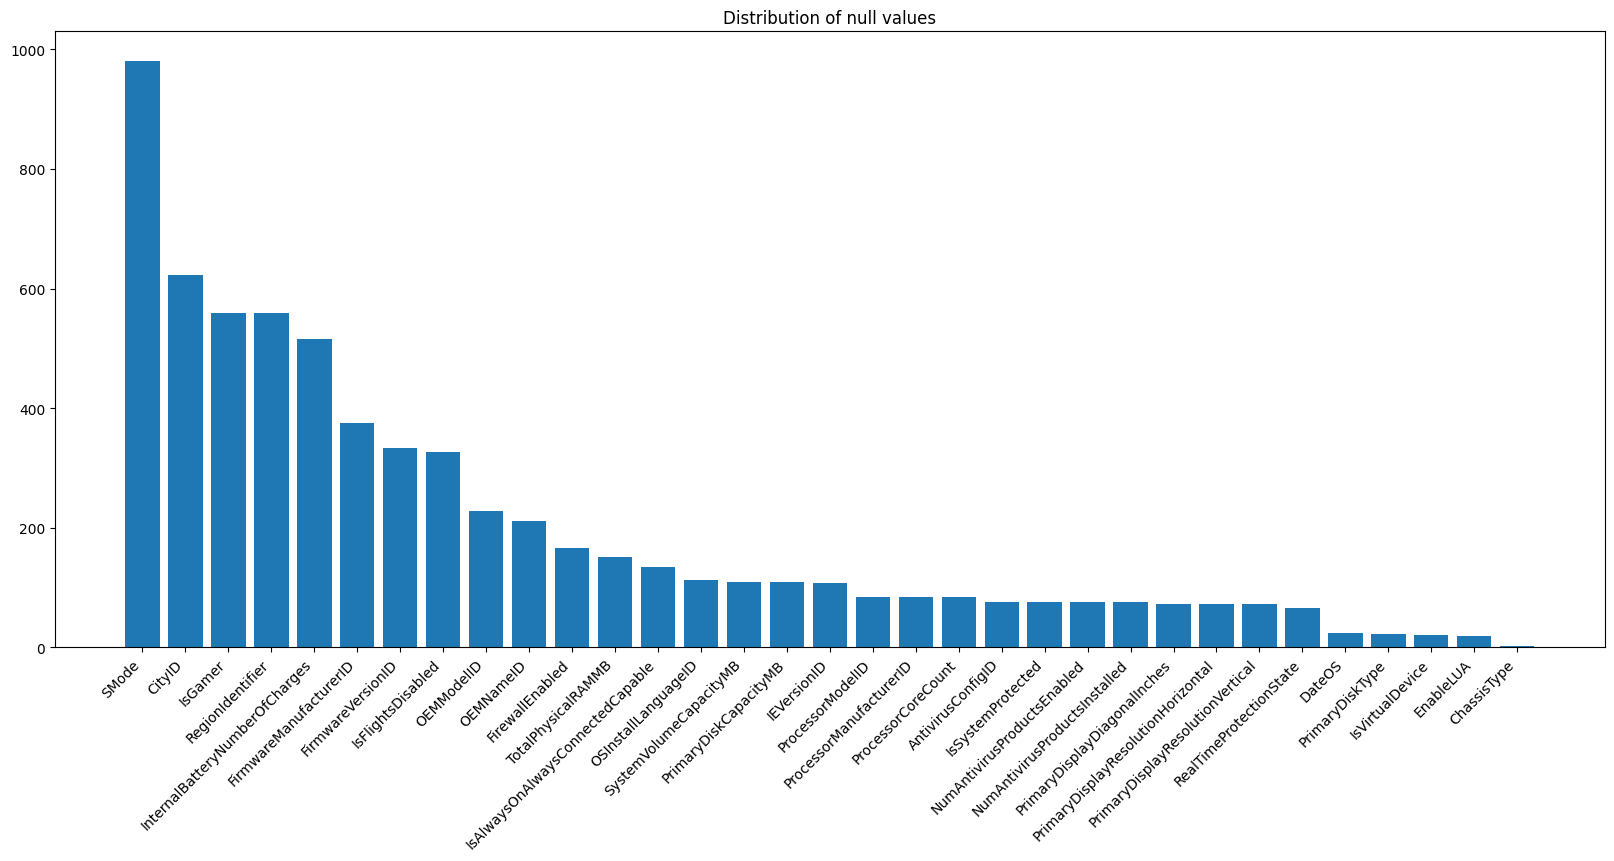

In [26]:
#Plot for the distribution of null values
plt.figure(figsize=(20,8))
x = missing_features.index
y = missing_features.values
plt.bar(x,y)
plt.xticks(rotation=45,ha='right')
plt.title("Distribution of null values")
plt.show()

<H2>Class Distribution in Binary Columns</H2>

In [27]:
#Binary columns
binary_columns = []
for col in X.columns:
    if len(train_data[col].value_counts()) == 2:
        binary_columns.append(col)
print(f"There are {len(binary_columns)} binary columns in the data set.")
print(binary_columns)

There are 15 binary columns in the data set.
['ProductName', 'IsPassiveModeEnabled', 'HasTpm', 'IsSystemProtected', 'SMode', 'FirewallEnabled', 'DeviceFamily', 'HasOpticalDiskDrive', 'IsPortableOS', 'IsSecureBootEnabled', 'IsVirtualDevice', 'IsTouchEnabled', 'IsPenCapable', 'IsAlwaysOnAlwaysConnectedCapable', 'IsGamer']


<h4>Visualization for distribution of classes</h4>

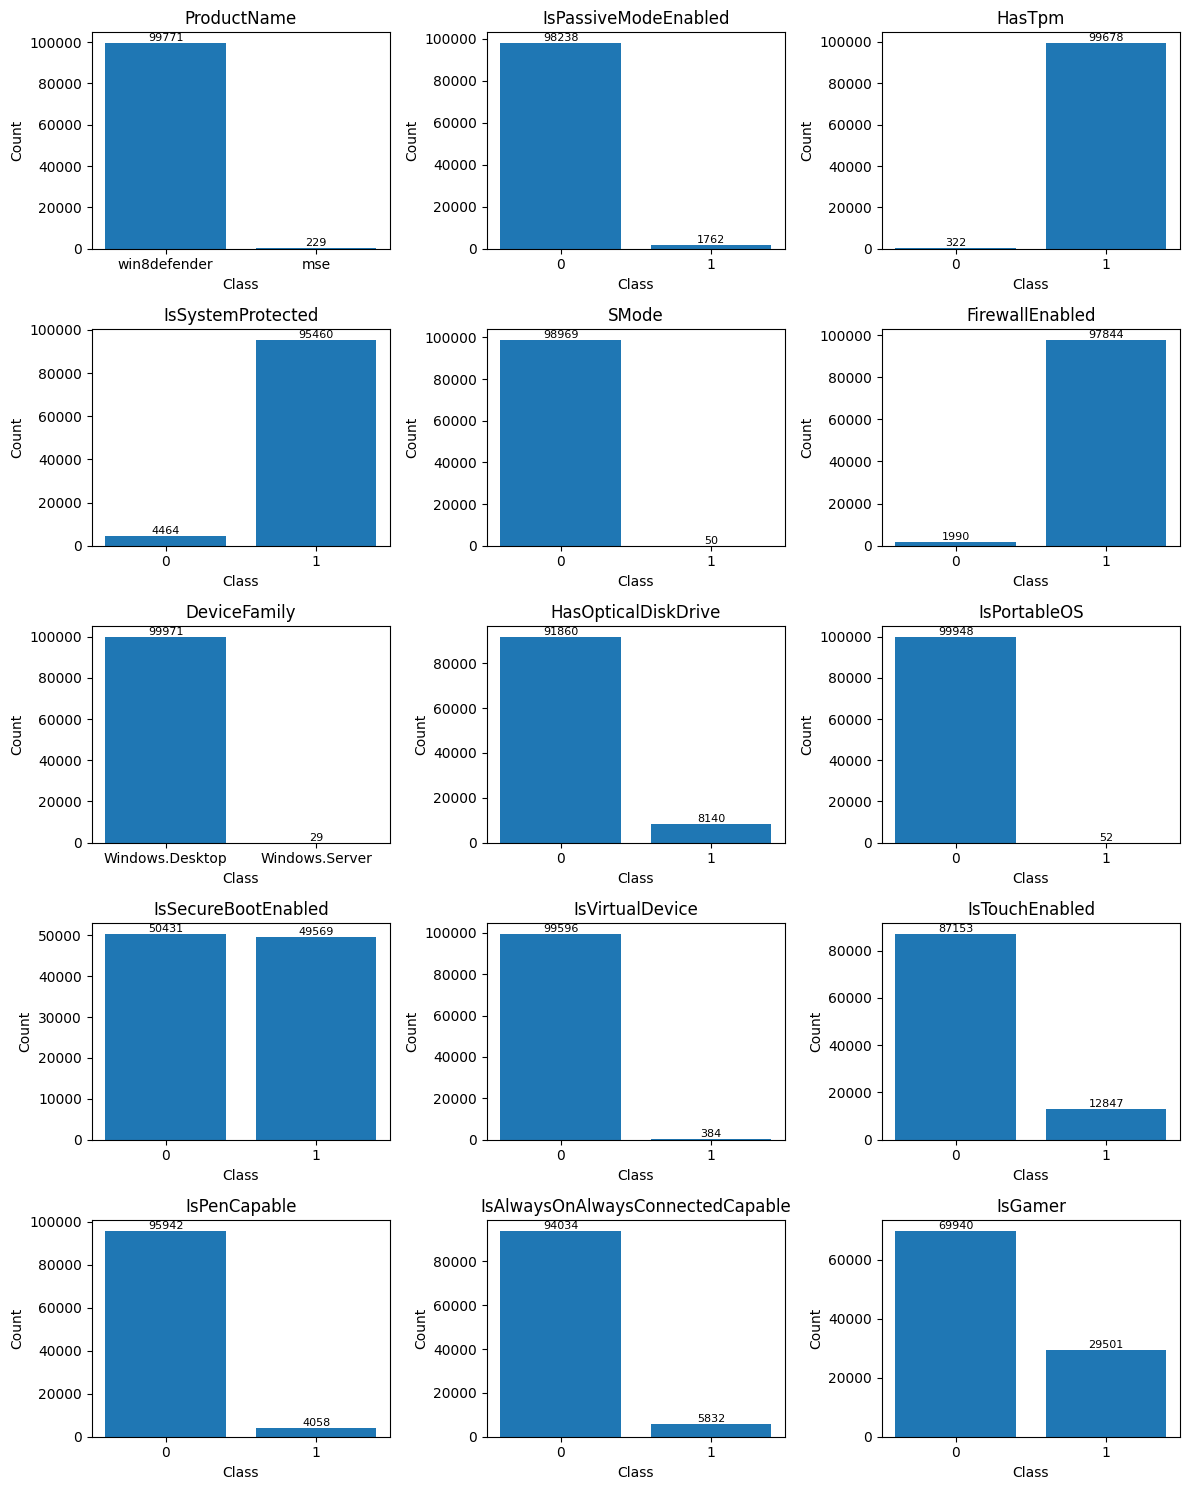

In [28]:
# Define number of rows & columns
n_cols = 3  # Number of columns per row
n_rows = -(-len(binary_columns) // n_cols)  # Ceiling division to get required rows

# Set a reasonable maximum width & height to avoid huge figures
max_width = 15   # Maximum figure width
max_height = 15  # Maximum figure height

fig_width = min(n_cols * 4, max_width)  
fig_height = min(n_rows * 3, max_height)  

fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height))  
axes = axes.flatten()  # Flatten in case of multiple rows

for i, col in enumerate(binary_columns):
    counts = train_data[col].value_counts()
    bars = axes[i].bar(counts.index, counts.values)  # Plot bar chart
    axes[i].set_title(col)
    axes[i].set_xticks([0, 1])  # Ensure binary labels (0,1)
    axes[i].set_xlabel("Class")
    axes[i].set_ylabel("Count")

    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2, height, f"{int(height)}", 
                     ha='center', va='bottom', fontsize=8)

# Hide unused subplots (if any)
for i in range(len(binary_columns), len(axes)):
    fig.delaxes(axes[i])  

plt.tight_layout()  # Adjust layout

plt.show()


<h3>Findings:</h3>

<p style="font-size:15px">1. Highly imbalanced features are: ProductName, IsPassiveModeEnabled, HasTpm, DeviceFamily,IsSystemProtected, SMode, FirewallEnabled, DeviceFamily, HasOpticalDiskDrive, IsPortableOS, IsVirtualDevice, IsTouchEnabled, IsPenCapable, IsAlwaysOnAlwaysConnectedCapable. This leads the model favor majority class and poor performance on minority class predictions.</p>   
<p style="font-size:15px">2. Slightly balanced data: IsGamer</p> 
<p style="font-size:15px">3. Balanced data: IsSecureBootEnabled. This will perform well and will not give any priority for any classes.</p>
<p style="font-size:15px">3. ProductName, HasTpm, DeviceFamily, IsPortableOS, IsVirtualDevice are having weightage for majority class more than 99%. So we can consider them as mostly constant and try to include it with the reduntant feature filteration. it may not contribute useful information. </p>


In [29]:
def reduntant_majority(df):
    print(f"Shape of data before dropping mostly constant features: {df.shape}")
    df.drop(columns=['ProductName', 'HasTpm', 'DeviceFamily', 'IsPortableOS', 'IsVirtualDevice'],inplace=True)
    print(f"Shape of data after dropping mostly constant features: {df.shape}")
    return df

<H2>Class Distribution of Numerical Columns</H2>

In [30]:
train_data[numerical_columns].drop(columns=[ 
    'IsPassiveModeEnabled', 'HasTpm', 'IsSystemProtected', 'SMode', 'FirewallEnabled', 
    'HasOpticalDiskDrive', 'IsPortableOS', 'IsSecureBootEnabled', 'IsVirtualDevice', 
    'IsTouchEnabled', 'IsPenCapable', 'IsAlwaysOnAlwaysConnectedCapable', 'IsGamer'
]).shape

(100000, 34)

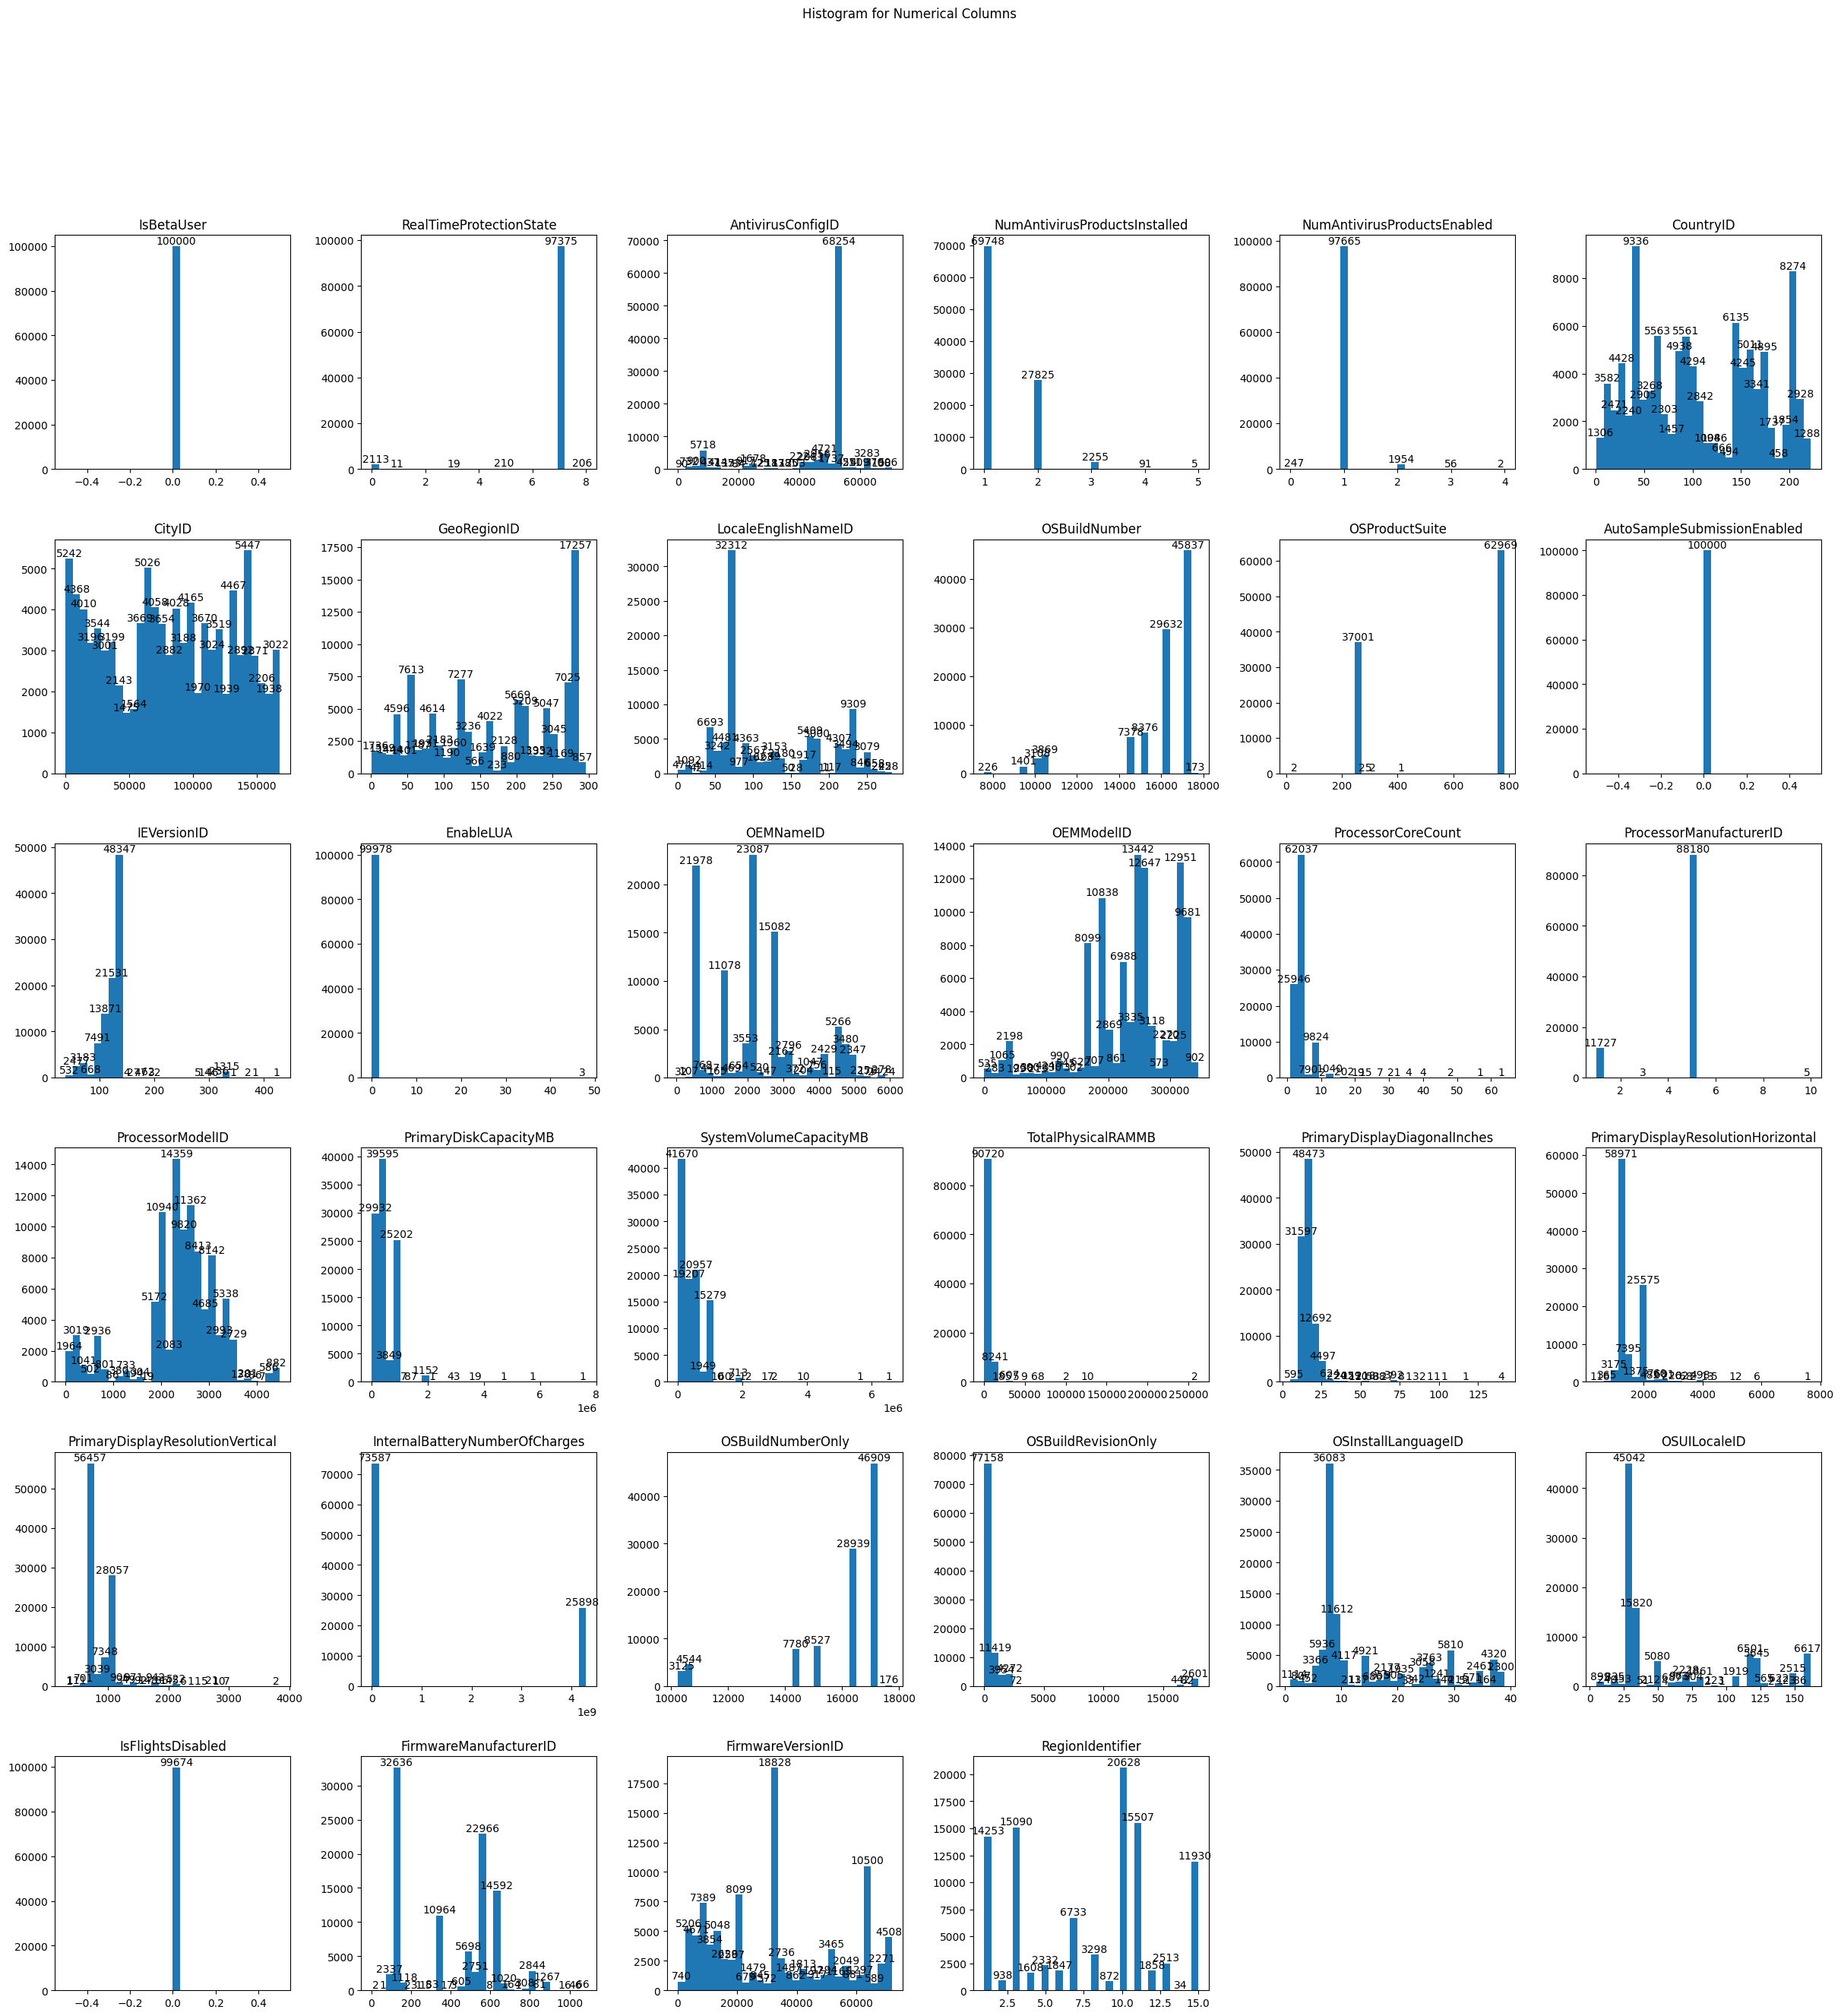

In [31]:
# Generate histograms for numerical columns
ax = train_data[numerical_columns].drop(columns=[ 
    'IsPassiveModeEnabled', 'HasTpm', 'IsSystemProtected', 'SMode', 'FirewallEnabled', 
    'HasOpticalDiskDrive', 'IsPortableOS', 'IsSecureBootEnabled', 'IsVirtualDevice', 
    'IsTouchEnabled', 'IsPenCapable', 'IsAlwaysOnAlwaysConnectedCapable', 'IsGamer'
]).hist(figsize=(30, 30), bins=30, grid=False)

plt.suptitle('Histogram for Numerical Columns')

# Iterate over each subplot to add values
for row in ax:
    for subplot in row:
        for patch in subplot.patches:
            height = patch.get_height()
            if height > 0:  # Only add labels if height > 0
                subplot.text(patch.get_x() + patch.get_width() / 2, height, 
                             f'{int(height)}', ha='center', va='bottom', fontsize=10)

plt.show()


<h3>Histogram of numerical variables : (distribution of 34 features)</h3> 
    <h5>* The x-axis of each histogram represents the range of values in that numerical column.</h>
    <h5>* The y-axis of each histogram represents the frequency of data points falls within each bins</h5>
    <h5>* Single Peak: 'IsFightDisabled', 'AutoSampleSubmissionEnabled' and 'IsBetaUser'</h5>
    <h5>* Extremely Dominent Features: </h5>
        <h5>1. RealTimeProtectionState - 7 overwhelmingly dominate the dataset. </h5>
        <h5>2. NumAntivirusProductsEnabled - 1 overwhelmingly dominate the dataset.</h5>
        <h5>3. EnableLUA - 1 overwhelmingly dominate the dataset.</h5>
        <h5>4. TotalPhysicalRAMMB - overwhelmingly dominate the dataset with a range of value.</h5>
        <h5>5. ProcessorManufacturerID - 5 overwhelmingly dominate the dataset.</h5>
    <h5>Multimodal: CountryID, CityID, GeopRegionID, LocalEnglishNameID, OEMNameID, OEMMOdelID, OSInstallLanguageID, OSUILocaleID, FirmwareManufacturerID, FirmwareVersionID, RegionIdentifier</h5>
    <h5>Right Skewed: NumAntivirousProductsInstalled, SystemVolumCapacityMB, PrimaryDisplyDiagonalInches, OSBuildRevisionOnly,</h5>
    <h5>Left Skewed: OSBuildNumber, OSProductSuit, IEVersionID(with some outliers), OSBuildNumber only</h5>
<h3>Findings:</h3>
    <h4>3 features containe only one unique value.</h4>
    <h4>Approx. 5 features having extremely dominent value.</h4>
    <h4>Features having similar pattern - More chances to become highly correlated:</h4>
        <h4>* OSInstallLanguageID - OSUILocaleID </h4>
        <h4>* OSBuildNumber - OSBuildNumberOnly </h4>
        <h4>* PrimaryDisplyResolutionHorizontal - PrimaryDisplyResolutionVertical </h4>
    <h4>Significant Outliers:</h4>
        <h4>* IEVersionID</h4>
        <h4>* OSBuildRevisionOnly</h4>
        <h4>* EnableLUA</h4>

In [33]:
train_data['InternalBatteryNumberOfCharges'].value_counts()

InternalBatteryNumberOfCharges
0.000000e+00    58047
4.294967e+09    25788
1.000000e+00      540
2.000000e+00      312
1.600000e+01      288
                ...  
1.080000e+03        1
3.903700e+04        1
5.490000e+02        1
2.565000e+03        1
7.968000e+03        1
Name: count, Length: 1760, dtype: int64

In [34]:
train_data['EnableLUA'].value_counts()

EnableLUA
1.0     99494
0.0       484
48.0        3
Name: count, dtype: int64

In [35]:
train_data['TotalPhysicalRAMMB'].value_counts()

TotalPhysicalRAMMB
4096.0     46544
8192.0     24883
2048.0     12050
16384.0     6197
6144.0      4579
           ...  
4086.0         1
3006.0         1
1013.0         1
4608.0         1
1023.0         1
Name: count, Length: 127, dtype: int64

In [36]:
train_data['ProcessorManufacturerID'].value_counts()

ProcessorManufacturerID
5.0     88180
1.0     11727
10.0        5
3.0         3
Name: count, dtype: int64

<h2>Correlation Matrix for Numerical Columns</h2>

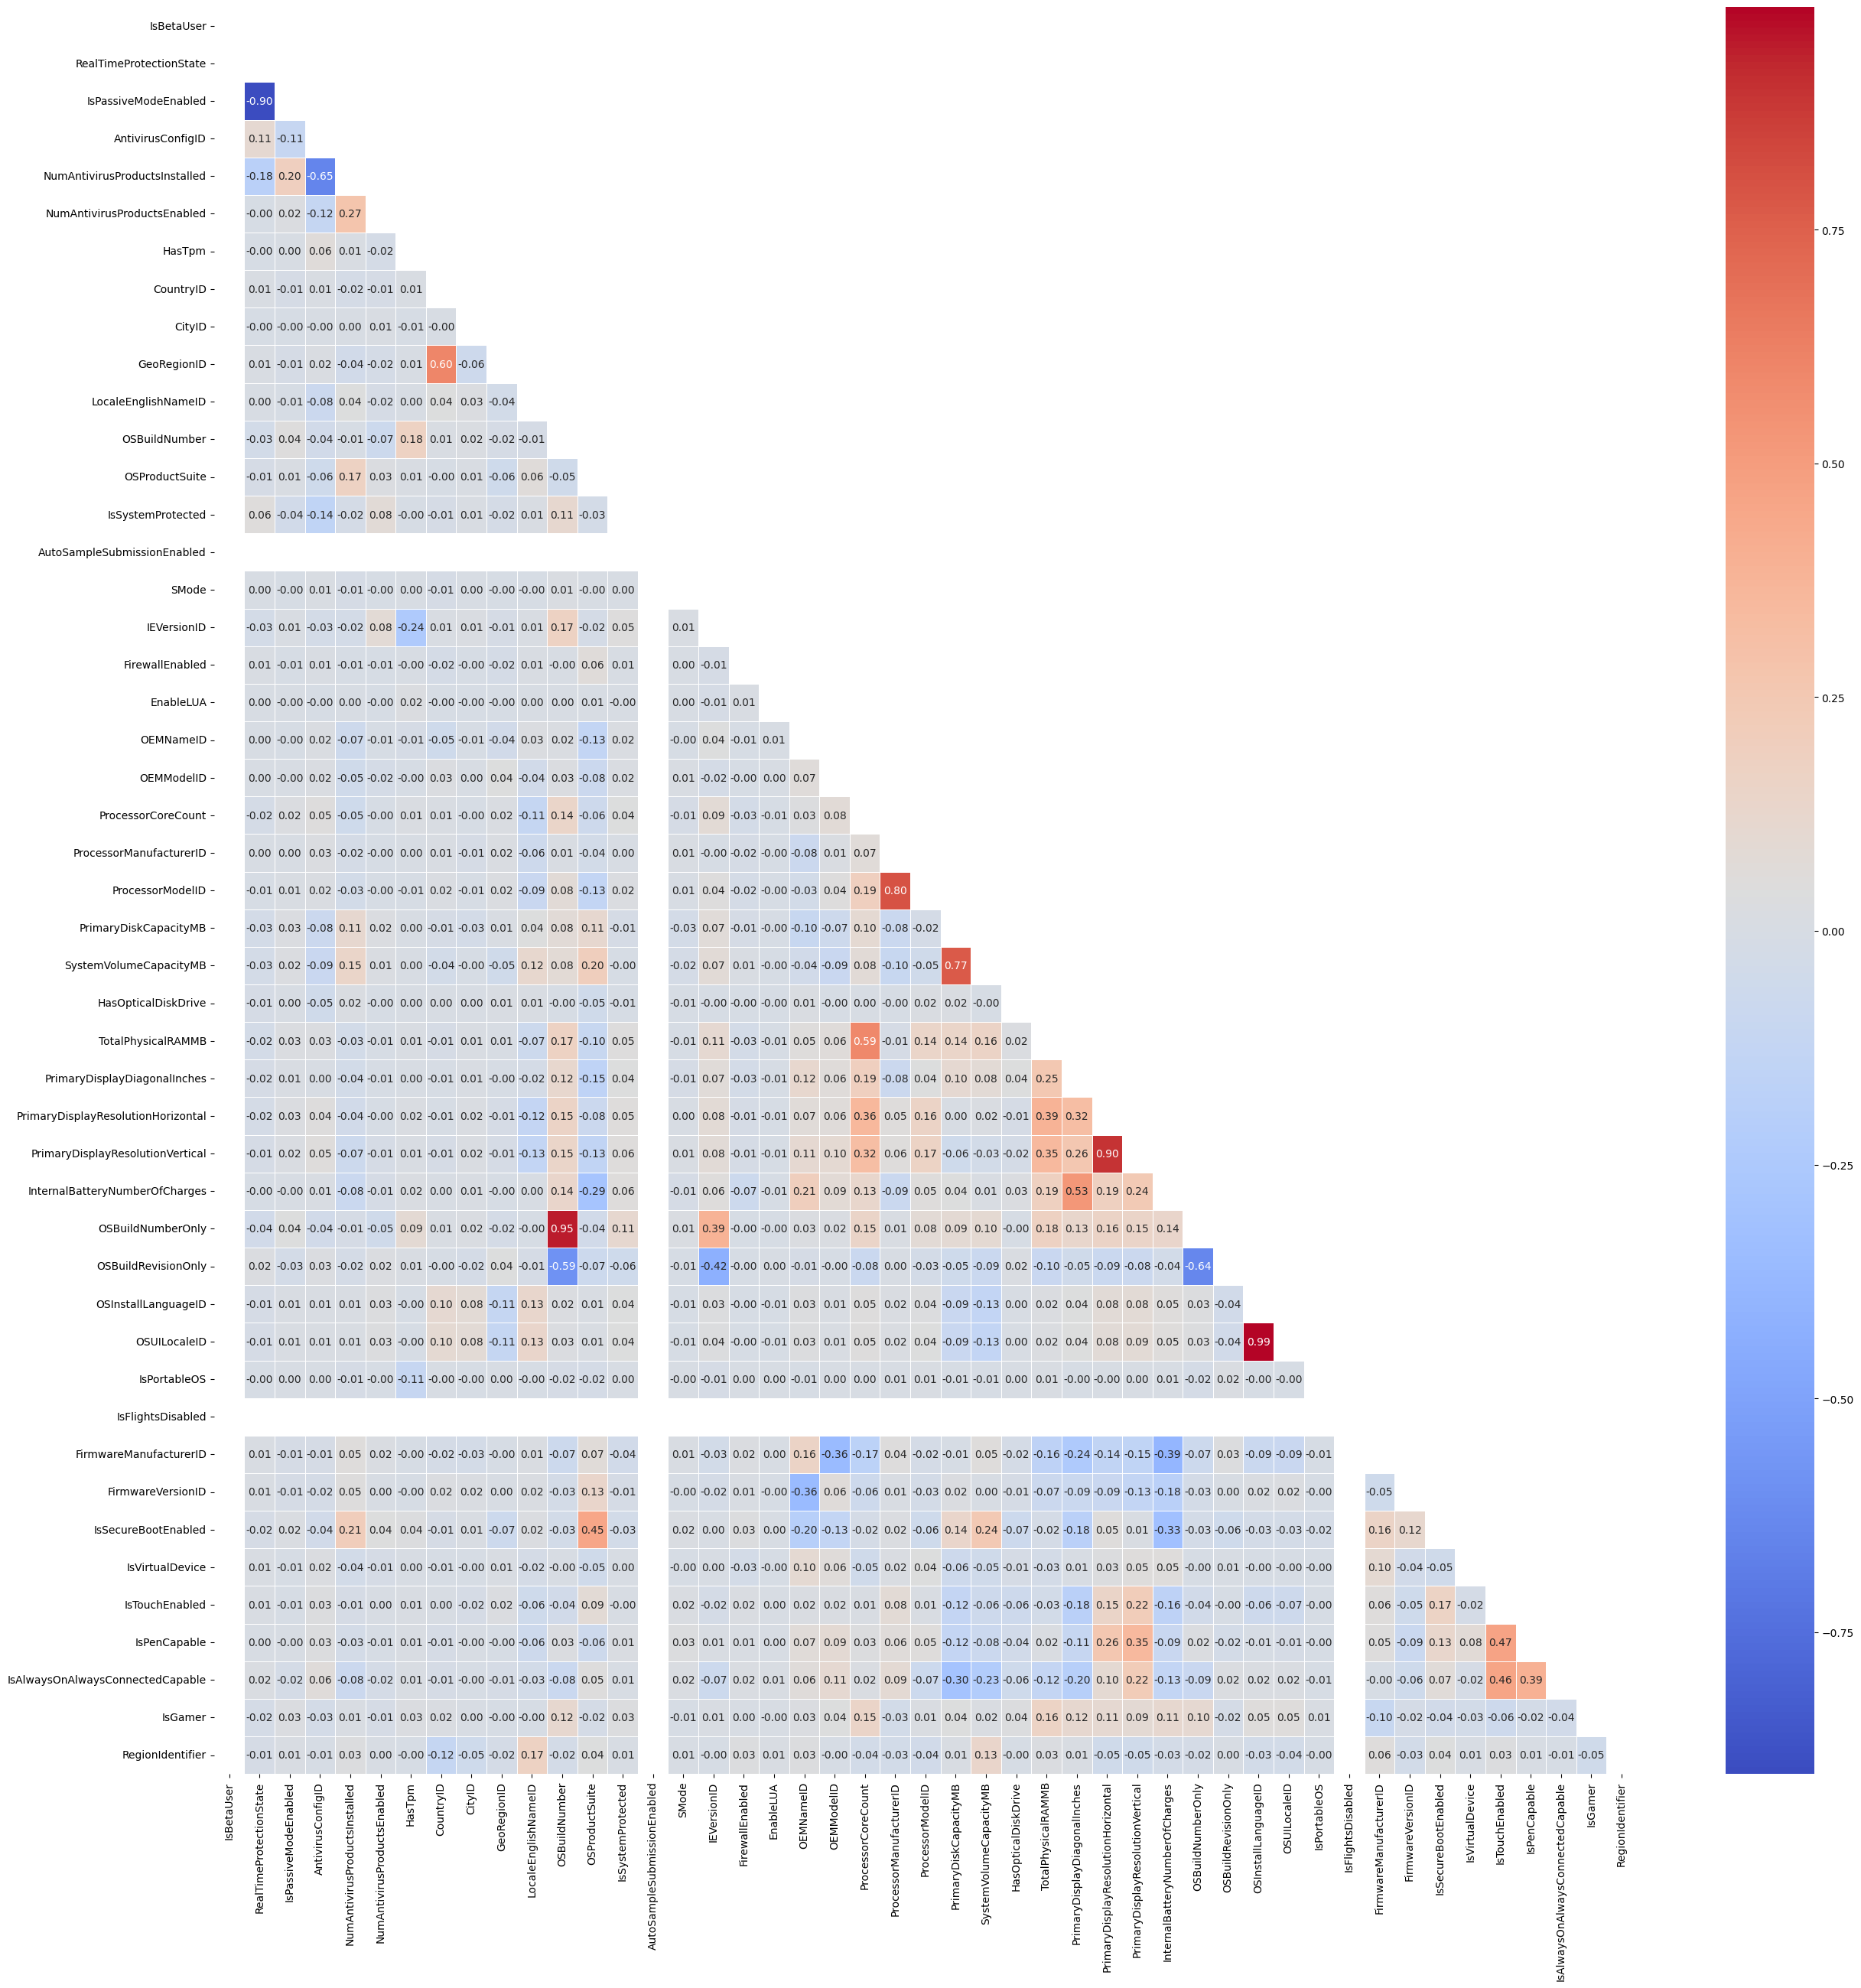

In [37]:
correlation_matrix = train_data[numerical_columns].corr()
plt.figure(figsize=(30, 30))
mask = np.triu(correlation_matrix)
sns.heatmap(correlation_matrix, annot=True,mask=mask, cmap="coolwarm", fmt=".2f",linewidths=0.5)
plt.show()

In [38]:

correlation_matrix = train_data.corr(numeric_only=True)
#set threshold 0.9
threshold = 0.89  

num = 0
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1,len(correlation_matrix.columns)): #avoid self correlation
        if abs(correlation_matrix.iloc[i,j])>threshold:
            num = num+1
            col1 = correlation_matrix.columns[i]
            col2 = correlation_matrix.columns[j]
            print(f"For the columns {col1} and {col2} has the correlation {correlation_matrix.iloc[i,j]}")
            print("\n")
            
    

For the columns RealTimeProtectionState and IsPassiveModeEnabled has the correlation -0.9014263817384273


For the columns OSBuildNumber and OSBuildNumberOnly has the correlation 0.9475643117921996


For the columns PrimaryDisplayResolutionHorizontal and PrimaryDisplayResolutionVertical has the correlation 0.8981739446126249


For the columns OSInstallLanguageID and OSUILocaleID has the correlation 0.9880823538835146




In [39]:
train_data['RealTimeProtectionState'].unique()

array([ 7.,  0.,  8., nan,  5.,  3.,  1.])

In [40]:
train_data['IsPassiveModeEnabled'].unique()

array([0, 1])

In [41]:
train_data['OSBuildNumber'].unique(),train_data['OSBuildNumberOnly'].unique()

(array([14393, 17134, 15063, 16299, 10586,  9600, 10240, 17744,  7601,
        17692, 17713, 17763, 17746, 17738, 17758, 17754, 17760, 17741,
        17751, 17755, 17735, 17730, 17672, 17686]),
 array([14393, 17134, 15063, 16299, 10586, 10240, 17744, 17692, 17760,
        17763, 17746, 17758, 17723, 17738, 17754, 17751, 17741, 17755,
        17735, 17672, 15060, 17133, 17686]))

In [42]:
train_data['OSInstallLanguageID'].unique(),train_data['OSUILocaleID'].unique()

(array([ 5.,  9.,  7., 37.,  8., 20.,  4.,  6., 10., 30., 24., 35., 33.,
        27., 17., 26., 29., 39., 12., 14., 25., 28., 19., 21., 18.,  1.,
        23., 15., nan, 36.,  2., 16.,  3., 31., 13., 34., 32., 11., 22.,
        38.]),
 array([ 26,  34,  30, 158,  31,  83,  24,  28,  35, 128, 109, 148, 140,
        120,  64, 119, 125, 160,  44,  49, 115,  68, 123,  74,  90,  72,
          5, 105,  58, 151,  11,  62,  20, 130,  48,  87, 156, 145,  17,
         12, 136,  38,  92, 159,  42, 121,  15,  29, 146,  75,  32, 162,
         99,   7,  54,   8,  36, 126,   6,  37, 161,  59,  46, 131]))

<h4>Using this data can clarify that the columns analysed from the histogram is correct in case of correlation</h4>
<h4>`RealTimeProtectionState` and 'IsPassiveModeEnabled' are correlated but having unique significance - Keep the columns</h4>
<h4>'OSUILocaleID' - 'OSInstallLanguageID' and OSBuildNumber - 'OSBuildNumberOnly' can be consider for drop</h4>

In [43]:
def remove_high_corr_colum(df):
    df.drop(columns=['OSUILocaleID','OSBuildNumberOnly'],inplace=True)
    return df

<H2>Class Distribution in Categorical Columns</H2>

In [44]:
small_class_cat_columns = []
for col in categorical_columns:
    if len(train_data[col].unique()) <=10 and len(train_data[col].unique()) != 2:
        small_class_cat_columns .append(col)
print(f"Number of features having classes less than or equal to 10 except the binary columns is {len(small_class_cat_columns)}")

Number of features having classes less than or equal to 10 except the binary columns is 13


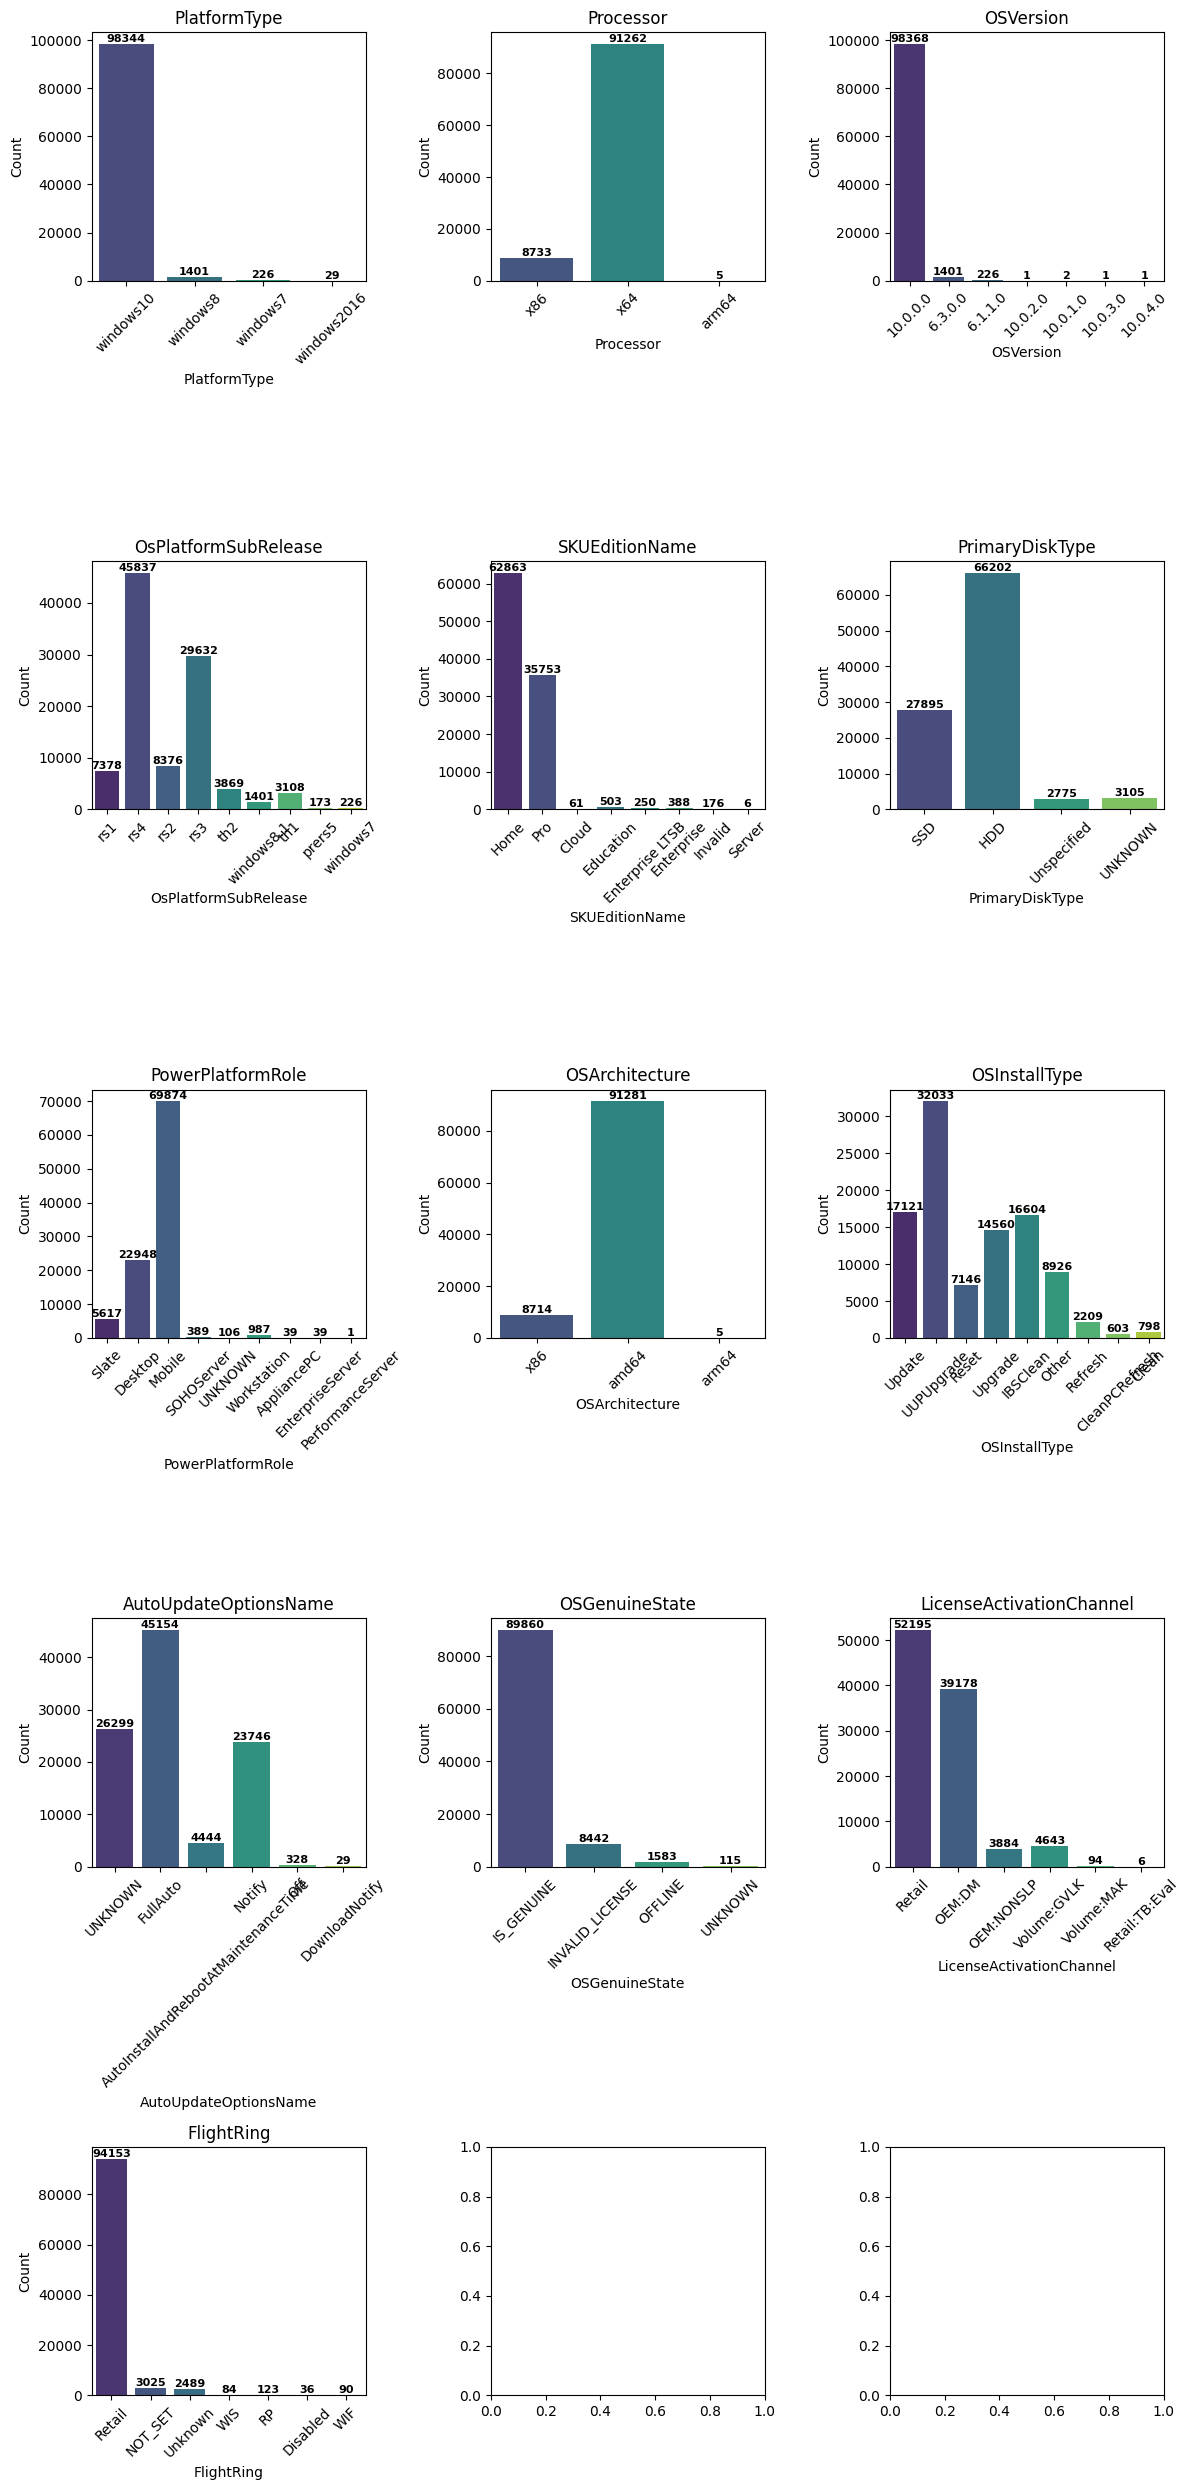

In [45]:
# Define number of rows & columns
n_cols = 3  # Number of columns per row
n_rows = -(-len(small_class_cat_columns) // n_cols)  # Ceiling division to get required rows

# Set a reasonable maximum width & height to avoid huge figures
max_width = 15   # Maximum figure width
max_height = 25  # Maximum figure height

fig_width = min(n_cols * 4, max_width)  
fig_height = min(n_rows * 5, max_height)  

fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height))  
axes = axes.flatten()  # Flatten in case of multiple rows

for i, col in enumerate(small_class_cat_columns):
    ax = axes[i]
    sns.countplot(x=train_data[col], palette="viridis", ax=ax)
    ax.set_title(f"{col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45)  # Rotate labels if needed

    # Add values above bars
    for p in ax.patches:
        height = p.get_height()
        if height > 0:  # Ensure labels are only added for non-zero bars
            ax.text(p.get_x() + p.get_width() / 2, height, f'{int(height)}', 
                    ha='center', va='bottom', fontsize=8, color='black', fontweight='bold')

plt.tight_layout()
plt.show()

<h3>Class distribution of categorical variables containes max 10 classes: (distribution of 13 features)</h3> 
    <h4>1. PlatformType: </h4>
        <h5>* It is the column of platform type derived from OS and Processor information </h5>
        <h5>* Majority of the collected data is of platform type Windows 10 (98344)</h5>
        <h5>* Remaining platform types Windows 8, Windows 7, and Windows 2016 are having very less data contribution.</h5>
    <h4>2. Processor: </h4>
        <h5>* It is the Processor Architecture of the Installed OS </h5>
        <h5>* Majority of the collected data is using x64</h5>
        <h5>* The category with relatively lower data is Arm64 </h5>
    <h4>3. OSVersion: </h4>
        <h5>* Majority class is 10.0.0.0</h5>
        <h5>* Remaining all having very least contribution </h5>
    <h4>4. OSArchitecture: </h4>
        <h5>* Majority data is kept by amd64</h5>
        <h5>* The category with minority class is Arm64 </h5>
    <h4>5. FlightRing: </h4>
        <h5>* Windows Update-related parameter that indicates the release channel or update ring a system is subscribed to.  </h5>
        <h5>* Majority class is Retail - Stable release used by general consumers</h5>
        <h5>* Minority class is the Flight Disabled </h5>
        <h5>* There are some Unknown values also in this feature. (84) </h5>
    * <h4>These are the features which contains high value majority class (more than 90%)</h4>
    * <h4>Some of the features are having unknown values.</h4>


<h3>The features contains Unknown or UNKNOWN values are:</h3>

In [46]:
train_data.eq('Unknown').sum().sort_values(ascending=False).head(3)

FlightRing     2489
ChassisType      59
MachineID         0
dtype: int64

In [47]:
train_data.eq('UNKNOWN').sum().sort_values(ascending=False).head(6)

AutoUpdateOptionsName    26299
PrimaryDiskType           3105
ChassisType                454
OSGenuineState             115
PowerPlatformRole          106
OSArchitecture               0
dtype: int64

In [48]:
test_data.eq('Unknown').sum().sort_values(ascending=False).head(3)

FlightRing     242
ChassisType      7
MachineID        0
dtype: int64

In [49]:
test_data.eq('UNKNOWN').sum().sort_values(ascending=False).head(6)

AutoUpdateOptionsName    2649
PrimaryDiskType           324
ChassisType                39
OSGenuineState             13
PowerPlatformRole           9
MachineID                   0
dtype: int64

<h4>Findings:</h4>
    <h5>* Unknown values are considered as null if the distribution of those are less than 2%, else keep it as a seperate class</h5>
    <h5>* ChassisType contains both 'UNKNOWN' and 'Unknown'</h5>
    <h5>* FlighRing: approx. 2% Unknown in both train_data and test_data </h5>
    <h5>* ChassisType: approx. 0.06% Unknown in train_data and 0.07% in test_data </h5>
    <h5>* AutoUpdateOptionsName: more than 20% UNKNOWN in both train_data and test_data </h5>
    <h5>* PrimaryDiskType : approx. 3% UNKNOWN in both train_data and test_data </h5>
    <h5>* ChassisType: approx. 0.4% UNKNOWN in both train_data and test_data </h5>
    <h5>* OSGenuineState: approx. 0.1% UNKNOWN in both train_data and test_data </h5>
    <h5>* PowerPlatformRole: approx. 0.1% UNKNOWN in both train_data and test_data </h5>
<h4>Remarks:</h4>
    <h5>Convert the combined unknown values, which contains less than 2% into null  </h5>
    <h5>Combine the 'UNKNOWN' and 'Unknown' values into a single 'Unknown'</h5>

In [50]:
def combine_unknown(df):
    df['ChassisType'].replace('UNKNOWN','Unknown',inplace=True)
    print("Combined - ChassisType")
    return df
def convert_unknown(df):
    df['ChassisType'].replace('Unknown',np.nan,inplace=True)
    df['OSGenuineState'].replace('UNKNOWN',np.nan,inplace=True)
    df['PowerPlatformRole'].replace('UNKNOWN',np.nan,inplace=True)
    print("Converted - ChassisType, OSGenuineState, PowerPlatformRole ")
    return df

<hr>

<h2>Detailed Analysis on some Features</h2>

<p style="font-size:18px">The 'FirewallEnabled' and 'IsSystemProtected' can be combine as new feature 'Security_Level' for a better performance, because both indicate security settings of the system. 
Can create categories as : High (both enabled), Medium( either one is enabled), Low(both are disabled) 

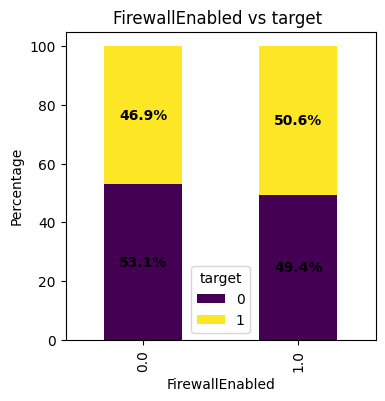

In [51]:
# Compute normalized counts (percentage)
cross_tab = pd.crosstab(train_data['FirewallEnabled'], target, normalize="index") * 100  # Normalize by row to get percentages

# Plot
fig, ax = plt.subplots(figsize=(4,4))
cross_tab.plot(kind="bar", stacked=True, colormap="viridis", ax=ax)

# Add percentage annotations
for i in range(len(cross_tab)):  # Iterate over categories in X
    cumulative_height = 0  # Initialize cumulative height for stacked bars
    for j, target_value in enumerate(cross_tab.columns):  # Iterate over target classes
        height = cross_tab.iloc[i, j]  # Get percentage value
        if height > 0:  # Avoid placing labels for zero values
            ax.text(i, cumulative_height + height / 2, f"{height:.1f}%", 
                    ha="center", va="center", fontsize=10, color="black", fontweight="bold")
        cumulative_height += height  # Update cumulative height

# Customize plot
plt.title("FirewallEnabled vs target ")
plt.xlabel('FirewallEnabled')
plt.ylabel("Percentage")
plt.show()

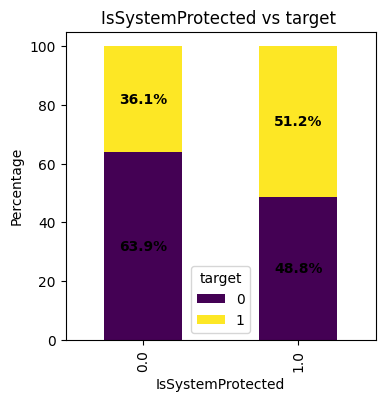

In [52]:
# Compute normalized counts (percentage)
cross_tab = pd.crosstab(train_data['IsSystemProtected'], target, normalize="index") * 100  # Normalize by row to get percentages

# Plot
fig, ax = plt.subplots(figsize=(4,4))
cross_tab.plot(kind="bar", stacked=True, colormap="viridis", ax=ax)

# Add percentage annotations
for i in range(len(cross_tab)):  # Iterate over categories in X
    cumulative_height = 0  # Initialize cumulative height for stacked bars
    for j, target_value in enumerate(cross_tab.columns):  # Iterate over target classes
        height = cross_tab.iloc[i, j]  # Get percentage value
        if height > 0:  # Avoid placing labels for zero values
            ax.text(i, cumulative_height + height / 2, f"{height:.1f}%", 
                    ha="center", va="center", fontsize=10, color="black", fontweight="bold")
        cumulative_height += height  # Update cumulative height

# Customize plot
plt.title("IsSystemProtected vs target ")
plt.xlabel('IsSystemProtected')
plt.ylabel("Percentage")
plt.show()

In [53]:
train_data['IsSystemProtected'].isna().sum()

76

In [54]:
train_data['FirewallEnabled'].isna().sum()

166

In [55]:
# def security_level(row):
#     if row['FirewallEnabled'] == 1 and row['IsSystemProtected'] ==1:
#         return 'High'
#     elif row['FirewallEnabled'] == 1 or row['IsSystemProtected'] ==1:
#         return "Medium"
#     else:
#         return "Low"

# train_data['SecurityLevel'] = train_data.apply(security_level,axis = 1)    

<h3 >IsSecureBootEnabled vs Target</h3>
As the 'IsSecureBootEnabled' column is balanced, lets visualize the distribution of target value for each class.

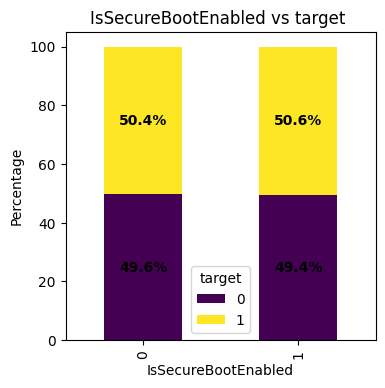

In [56]:
# Compute normalized counts (percentage)
cross_tab = pd.crosstab(train_data['IsSecureBootEnabled'], target, normalize="index") * 100  # Normalize by row to get percentages

# Plot
fig, ax = plt.subplots(figsize=(4,4))
cross_tab.plot(kind="bar", stacked=True, colormap="viridis", ax=ax)

# Add percentage annotations
for i in range(len(cross_tab)):  # Iterate over categories in X
    cumulative_height = 0  # Initialize cumulative height for stacked bars
    for j, target_value in enumerate(cross_tab.columns):  # Iterate over target classes
        height = cross_tab.iloc[i, j]  # Get percentage value
        if height > 0:  # Avoid placing labels for zero values
            ax.text(i, cumulative_height + height / 2, f"{height:.1f}%", 
                    ha="center", va="center", fontsize=10, color="black", fontweight="bold")
        cumulative_height += height  # Update cumulative height

# Customize plot
plt.title("IsSecureBootEnabled vs target ")
plt.xlabel('IsSecureBootEnabled')
plt.ylabel("Percentage")
plt.show()

In [57]:
train_data.groupby('IsSecureBootEnabled')['target'].value_counts()

IsSecureBootEnabled  target
0                    1         25428
                     0         25003
1                    1         25097
                     0         24472
Name: count, dtype: int64

<h3>Findings of IsSecureBootEnabled and target</h3>
<p style="font-size:15px"> 1. 50.4% of the systems with secure boot disabled are infected by malwares </p>
<p style="font-size:15px"> 2. 49.6% of the systems with secure boot disabled are not infected by malwares </p>
<p style="font-size:15px"> 3. 50.6% of the systems with secure boot enabled are infected by malwares </p>
<p style="font-size:15px"> 4. 49.4% of the systems with secure boot disabled are not infected by malwares </p>
Each classes has an equal proportion of both target values. The 'IsSecureBootEnabled' might not be a strong predictor of target. 

> <h3>IsGamer vs Target</h3>

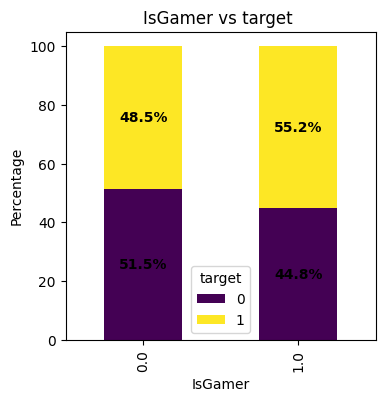

In [58]:
# Compute normalized counts (percentage)
cross_tab = pd.crosstab(train_data['IsGamer'], target, normalize="index") * 100  # Normalize by row to get percentages

# Plot
fig, ax = plt.subplots(figsize=(4,4))
cross_tab.plot(kind="bar", stacked=True, colormap="viridis", ax=ax)

# Add percentage annotations
for i in range(len(cross_tab)):  # Iterate over categories in X
    cumulative_height = 0  # Initialize cumulative height for stacked bars
    for j, target_value in enumerate(cross_tab.columns):  # Iterate over target classes
        height = cross_tab.iloc[i, j]  # Get percentage value
        if height > 0:  # Avoid placing labels for zero values
            ax.text(i, cumulative_height + height / 2, f"{height:.1f}%", 
                    ha="center", va="center", fontsize=10, color="black", fontweight="bold")
        cumulative_height += height  # Update cumulative height

# Customize plot
plt.title("IsGamer vs target ")
plt.xlabel('IsGamer')
plt.ylabel("Percentage")
plt.show()

<h3>Findings of IsGamer and target</h3>
<p style="font-size:15px"> 1. 48.5% of the non gamer systems are infected by malwares </p>
<p style="font-size:15px"> 2. 51.5% of the non gamer systems are not infected by malwares </p>
<p style="font-size:15px"> 3. 55.2% of the gamer systems are infected by malwares </p>
<p style="font-size:15px"> 4. 44.8% of the gamer systems are not infected by malwares </p>
Each classes has approx. equal proportion of both target values. 

<h3>HasOpticalDiskDrive vs Target</h3>

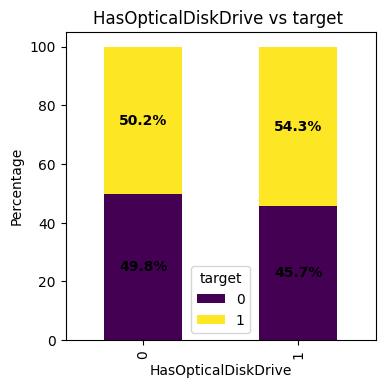

In [59]:
# Compute normalized counts (percentage)
cross_tab = pd.crosstab(train_data['HasOpticalDiskDrive'], target, normalize="index") * 100  # Normalize by row to get percentages

# Plot
fig, ax = plt.subplots(figsize=(4,4))
cross_tab.plot(kind="bar", stacked=True, colormap="viridis", ax=ax)

# Add percentage annotations
for i in range(len(cross_tab)):  # Iterate over categories in X
    cumulative_height = 0  # Initialize cumulative height for stacked bars
    for j, target_value in enumerate(cross_tab.columns):  # Iterate over target classes
        height = cross_tab.iloc[i, j]  # Get percentage value
        if height > 0:  # Avoid placing labels for zero values
            ax.text(i, cumulative_height + height / 2, f"{height:.1f}%", 
                    ha="center", va="center", fontsize=10, color="black", fontweight="bold")
        cumulative_height += height  # Update cumulative height

# Customize plot
plt.title("HasOpticalDiskDrive vs target ")
plt.xlabel('HasOpticalDiskDrive')
plt.ylabel("Percentage")
plt.show()

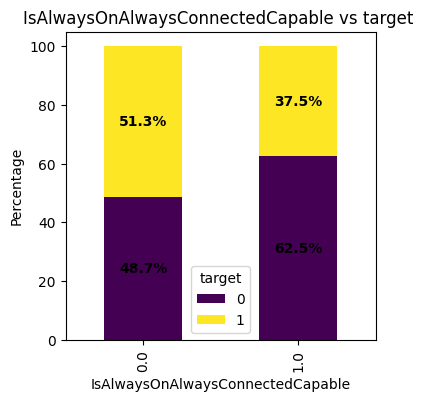

In [60]:
# Compute normalized counts (percentage)
cross_tab = pd.crosstab(train_data['IsAlwaysOnAlwaysConnectedCapable'], target, normalize="index") * 100  # Normalize by row to get percentages

# Plot
fig, ax = plt.subplots(figsize=(4,4))
cross_tab.plot(kind="bar", stacked=True, colormap="viridis", ax=ax)

# Add percentage annotations
for i in range(len(cross_tab)):  # Iterate over categories in X
    cumulative_height = 0  # Initialize cumulative height for stacked bars
    for j, target_value in enumerate(cross_tab.columns):  # Iterate over target classes
        height = cross_tab.iloc[i, j]  # Get percentage value
        if height > 0:  # Avoid placing labels for zero values
            ax.text(i, cumulative_height + height / 2, f"{height:.1f}%", 
                    ha="center", va="center", fontsize=10, color="black", fontweight="bold")
        cumulative_height += height  # Update cumulative height

# Customize plot
plt.title("IsAlwaysOnAlwaysConnectedCapable vs target ")
plt.xlabel('IsAlwaysOnAlwaysConnectedCapable')
plt.ylabel("Percentage")
plt.show()

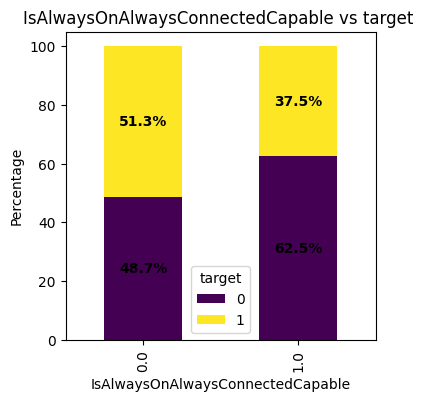

In [61]:
# Compute normalized counts (percentage)
cross_tab = pd.crosstab(train_data['IsAlwaysOnAlwaysConnectedCapable'], target, normalize="index") * 100  # Normalize by row to get percentages

# Plot
fig, ax = plt.subplots(figsize=(4,4))
cross_tab.plot(kind="bar", stacked=True, colormap="viridis", ax=ax)

# Add percentage annotations
for i in range(len(cross_tab)):  # Iterate over categories in X
    cumulative_height = 0  # Initialize cumulative height for stacked bars
    for j, target_value in enumerate(cross_tab.columns):  # Iterate over target classes
        height = cross_tab.iloc[i, j]  # Get percentage value
        if height > 0:  # Avoid placing labels for zero values
            ax.text(i, cumulative_height + height / 2, f"{height:.1f}%", 
                    ha="center", va="center", fontsize=10, color="black", fontweight="bold")
        cumulative_height += height  # Update cumulative height

# Customize plot
plt.title("IsAlwaysOnAlwaysConnectedCapable vs target ")
plt.xlabel('IsAlwaysOnAlwaysConnectedCapable')
plt.ylabel("Percentage")
plt.show()

<h2>Handling Date Columns</h2>
<h4>2 Date Columns - DateAS, DateOS</h4>

In [62]:
len(train_data['DateOS'].unique()),len(train_data['DateAS'].unique())

(113, 2695)

In [63]:
def handle_dateAS(df):
    print(f"Shape of data before DateAS conversion{df.shape}")
    df['DateAS'] = pd.to_datetime(df['DateAS'], errors='coerce')
    df['DateASYear'] = df['DateAS'].dt.year
    df['DateASMonth'] = df['DateAS'].dt.month
    df['DateASDay'] = df['DateAS'].dt.day
    df.drop('DateAS',axis=1,inplace=True)
    print(f"Shape of data after DateAS conversion{df.shape}")
    return df
    
def handle_dateOS(df):
    print(f"Shape of data before DateOS conversion{df.shape}")
    df['DateOS'] = pd.to_datetime(df['DateOS'], errors='coerce')
    df['DateOSYear'] = df['DateOS'].dt.year
    df['DateOSMonth'] = df['DateOS'].dt.month
    df['DateOSDay'] = df['DateOS'].dt.day
    df.drop('DateOS',axis=1,inplace=True)
    print(f"Shape of data after DateAS conversion{df.shape}")
    return df



<hr>

<u><h1 style="text-align:center;" >Feature Engineering</h1></u>

In [64]:
train_data = pd.read_csv('/kaggle/input/System-Threat-Forecaster/train.csv')
test_data = pd.read_csv('/kaggle/input/System-Threat-Forecaster/test.csv')
print(train_data.shape,test_data.shape)

(100000, 76) (10000, 75)


In [65]:
#Removing duplicate rows
train_data = remove_duplicate(train_data)
print("\n\n")

#Drop feature contains only single unique value
train_data = drop_single_class_column(train_data)
print("\n")
test_data = drop_single_class_column(test_data)
print("\n\n")

# drop columns with high cardinality - n number of unique values
test_data = drop_high_cardinality_column(test_data)
print("\n")
train_data = drop_high_cardinality_column(train_data)
print("\n\n")

#Drop the high correlated column
print(f"Shape of train_data before removing high correlation{train_data.shape}")
train_data = remove_high_corr_colum(train_data)
print(f"Shape of train_data after removing high correlation{train_data.shape}")
print("\n")
print(f"Shape of test_data before removing high correlation{test_data.shape}")
test_data = remove_high_corr_colum(test_data)
print(f"Shape of test_data after removing high correlation{test_data.shape}")
print("\n\n")

#Combine unknown 
train_data = combine_unknown(train_data)
print("\n")
test_data = combine_unknown(test_data)
print("\n\n")

#Convert unknowns to null
train_data = convert_unknown(train_data)
test_data = convert_unknown(test_data)
print("\n\n")

# #Convert Date
# train_data = handle_dateAS(train_data)
# print("\n")
# test_data = handle_dateAS(test_data)
# print("\n")
# train_data = handle_dateOS(train_data)
# print("\n")
# test_data = handle_dateOS(test_data)

Number of duplicate rows in the train_data is:165
train_data shape after removing duplicate rows (99835, 76)



data shape before dropping columns with single class(99835, 76)
data shape after dropping columns with single class(99835, 74)


data shape before dropping columns with single class(10000, 75)
data shape after dropping columns with single class(10000, 73)



data shape before dropping high cardinality feature(10000, 73)
data shape after dropping high cardinality feature(10000, 72)


data shape before dropping high cardinality feature(99835, 74)
data shape after dropping high cardinality feature(99835, 73)



Shape of train_data before removing high correlation(99835, 73)
Shape of train_data after removing high correlation(99835, 71)


Shape of test_data before removing high correlation(10000, 72)
Shape of test_data after removing high correlation(10000, 70)



Combined - ChassisType


Combined - ChassisType



Converted - ChassisType, OSGenuineState, PowerPlatformRole 
Conver

<h4>Formatting Date columns reducing the accuracy</h4>

In [66]:
def cat_num(df):
    categorical_columns = df.drop('target',axis = 1).select_dtypes(include='object').columns.tolist()
    numerical_columns = df.drop('target',axis = 1).select_dtypes(include='number').columns.tolist()
    print(f"Data contains {len(categorical_columns)} categorical columns and {len(numerical_columns)} numerical columns.")
    return categorical_columns,numerical_columns

<h2>Outliers</h2>

In [67]:
catgorical_columns,numerical_columns = cat_num(train_data)

Data contains 27 categorical columns and 43 numerical columns.


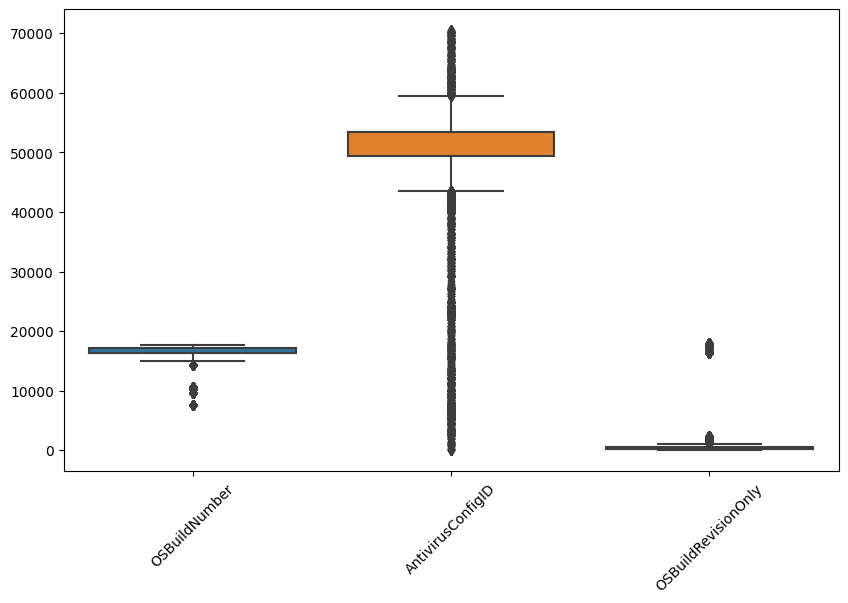

In [68]:
plt.figure(figsize=(10, 6))  # Adjust width (15) and height (6)
sns.boxplot(data=train_data[['OSBuildNumber','AntivirusConfigID','OSBuildRevisionOnly']])  # Ensure 'data=' is used
plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
plt.show()

In [69]:
Q1 = train_data[numerical_columns].quantile(0.25) #First quartile
Q3 = train_data[numerical_columns].quantile(0.75) #third quartile
IQR = Q3 - Q1 #Interquartile 

outliers = (train_data[numerical_columns] < (Q1 - 1.5 * IQR)) | (train_data[numerical_columns] > (Q3 + 1.5 * IQR))
total_outliers = outliers.sum().sum() #Total outliers
total_values = np.prod(train_data[numerical_columns].shape)  # Rows * Columns
# Percentage of outliers
outlier_percentage = (total_outliers / total_values) * 100
print("Outliers")
print("\n")
print(f"Total Outlier Percentage: {outlier_percentage:.2f}%")
print("\n")
print("Outliers in each feature")
print("_________________________")
print("\n")
print(outliers.sum())  # Count of outliers per column

Outliers


Total Outlier Percentage: 3.93%


Outliers in each feature
_________________________


RealTimeProtectionState                2557
IsPassiveModeEnabled                   1761
AntivirusConfigID                     19545
NumAntivirusProductsInstalled            95
NumAntivirusProductsEnabled            2253
HasTpm                                  322
CountryID                                 0
CityID                                    0
GeoRegionID                               0
LocaleEnglishNameID                       0
OSBuildNumber                         15954
OSProductSuite                            0
IsSystemProtected                      4455
AutoSampleSubmissionEnabled               0
SMode                                    50
IEVersionID                            4937
FirewallEnabled                        1987
EnableLUA                               484
OEMNameID                             10256
OEMModelID                              745
ProcessorCoreCount    

<h3>Findings:</h3>
<h4>The train_data contains only 4.27% of outlier.</h4>
<h4>Keep outliers for non sensitive models like Random Forest, XGBoost</h4>
<h4>Cap the outlier with upper or lower for sensitive models like Linear Regression, SVM</h4>

In [70]:
def cap_outlier(df): #Replace extreme values with upper/lower bounds
    df = df.clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR, axis=1)
    return df

In [82]:
#Cap the outliers 
train_data[numerical_columns] = cap_outlier(train_data[numerical_columns])
print(f"train_data after cap outliers")
train_data.head()

train_data after cap outliers


,ProductName,EngineVersion,AppVersion,SignatureVersion,RealTimeProtectionState,IsPassiveModeEnabled,AntivirusConfigID,NumAntivirusProductsInstalled,NumAntivirusProductsEnabled,HasTpm,CountryID,CityID,GeoRegionID,LocaleEnglishNameID,PlatformType,Processor,OSVersion,OSBuildNumber,OSProductSuite,OsPlatformSubRelease,OSBuildLab,SKUEditionName,IsSystemProtected,AutoSampleSubmissionEnabled,SMode,IEVersionID,FirewallEnabled,EnableLUA,MDC2FormFactor,DeviceFamily,OEMNameID,OEMModelID,ProcessorCoreCount,ProcessorManufacturerID,ProcessorModelID,PrimaryDiskCapacityMB,PrimaryDiskType,SystemVolumeCapacityMB,HasOpticalDiskDrive,TotalPhysicalRAMMB,ChassisType,PrimaryDisplayDiagonalInches,PrimaryDisplayResolutionHorizontal,PrimaryDisplayResolutionVertical,PowerPlatformRole,InternalBatteryNumberOfCharges,NumericOSVersion,OSArchitecture,OSBranch,OSBuildRevisionOnly,OSEdition,OSSkuFriendlyName,OSInstallType,OSInstallLanguageID,AutoUpdateOptionsName,IsPortableOS,OSGenuineState,LicenseActivationChannel,FlightRing,FirmwareManufacturerID,FirmwareVersionID,IsSecureBootEnabled,IsVirtualDevice,IsTouchEnabled,IsPenCapable,IsAlwaysOnAlwaysConnectedCapable,IsGamer,RegionIdentifier,DateAS,DateOS,target
0,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1003.0,7.0,0,53447.0,1.0,1.0,1,51,120232.0,98.0,103,windows10,x86,10.0.0.0,15046.5,768,rs1,14393.2214.x86fre.rs1_release_1.180402-1758,Home,1.0,0,0.0,98.0,1.0,1.0,SmallTablet,Windows.Desktop,561.0,330367.0,4.0,5.0,1850.0,15028.0,SSD,14348.0,0,1024.0,Notebook,8.95,800.0,1280.0,Slate,1.420000e+02,10.0.14393.2214,x86,rs1_release,1117,Core,CORE,Update,5.0,UNKNOWN,0,IS_GENUINE,Retail,Retail,513.0,21964.0,0,0.0,0,0,0.0,0.0,6.0,2018-09-10 10:11:00,2018-04-17,0
1,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1465.0,7.0,0,53447.0,1.0,1.0,1,141,112854.0,167.0,227,windows10,x64,10.0.0.0,17134.0,256,rs4,17134.1.amd64fre.rs4_release.180410-1804,Pro,1.0,0,0.0,137.0,1.0,1.0,AllInOne,Windows.Desktop,2668.0,25212.0,4.0,5.0,2407.0,953869.0,HDD,952592.0,0,4096.0,AllinOne,19.40,1600.0,900.0,Desktop,4.294967e+09,10.0.17134.228,amd64,rs4_release,228,Professional,PROFESSIONAL,UUPUpgrade,9.0,FullAuto,0,IS_GENUINE,OEM:DM,Retail,628.0,44548.0,1,0.0,0,0,0.0,0.0,10.0,2018-08-16 00:01:00,2018-08-14,1
2,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1546.0,7.0,0,53447.0,1.0,1.0,1,51,41759.0,98.0,103,windows10,x64,10.0.0.0,17134.0,768,rs4,17134.1.amd64fre.rs4_release.180410-1804,Home,1.0,0,0.0,137.0,1.0,1.0,Desktop,Windows.Desktop,3035.0,263666.0,4.0,5.0,2719.0,228936.0,SSD,228321.0,0,8192.0,Desktop,22.15,1920.0,1080.0,Desktop,4.294967e+09,10.0.17134.285,amd64,rs4_release,285,Core,CORE,Reset,5.0,FullAuto,0,IS_GENUINE,OEM:NONSLP,Retail,142.0,9414.0,0,0.0,0,0,0.0,1.0,6.0,2018-09-20 23:20:00,2018-09-11,1
3,win8defender,1.1.15200.1,4.12.17007.18011,1.275.1141.0,7.0,0,46413.0,2.0,1.0,1,68,19507.0,276.0,74,windows10,x64,10.0.0.0,15063.0,768,rs2,15063.0.amd64fre.rs2_release.170317-1834,Home,1.0,0,0.0,108.0,1.0,1.0,Notebook,Windows.Desktop,2102.0,242491.0,4.0,5.0,3410.0,1907729.0,HDD,1008993.5,0,8192.0,Notebook,15.50,1366.0,768.0,Mobile,0.000000e+00,10.0.15063.850,amd64,rs2_release,850,Core,CORE,Upgrade,7.0,UNKNOWN,0,IS_GENUINE,OEM:DM,Retail,554.0,33060.0,1,0.0,0,0,0.0,0.0,12.0,2018-09-14 00:32:00,2018-01-03,1
4,win8defender,1.1.15200.1,4.13.17134.228,1.275.1283.0,7.0,0,43529.5,2.0,1.0,1,43,117801.0,53.0,42,windows10,x86,10.0.0.0,17134.0,256,rs4,17134.1.x86fre.rs4_release.180410-1804,Pro,1.0,0,0.0,137.0,1.0,1.0,Desktop,Windows.Desktop,2668.0,257309.0,2.0,5.0,4170.5,305245.0,HDD,52804.0,0,2048.0,Desktop,20.00,1600.0,900.0,Desktop,4.294967e+09,10.0.17134.285,x86,rs4_release,285,Professional,PROFESSIONAL,UUPUpgrade,37.0,FullAuto,0,IS_GENUINE,Retail,Retail,628.0,13224.0,0,0.0,0,0,0.0,1.0,7.0,2018-09-15 19:34:00,2018-09-11,0


<u><h2 style="text-align:center;" >Data Preprocessing</h2></u>

In [83]:
train_data.shape,test_data.shape

((99835, 71), (10000, 70))

In [84]:
X_train,y = train_data.drop(columns=['target']),train_data['target']

In [85]:
categorical_columns,numerical_columns = cat_num(train_data)

Data contains 27 categorical columns and 43 numerical columns.


<h3>Pipeline Process for Imputation - Encoding - Scaling</h3>
<h4>Categorical Features: Imputed with most frequent method -> Encoded with Ordinal Encode </h4>
<h4>Numerical Features: Imputed with most frequent(as it continains categorical behavioual numerical values) --> MinMaxScale</h4>
<h4>Scaling only for numerical columns - categorical values do not have a numerical meaning, could distort relationship - Scaling is for continous data</h4>

In [86]:
categorical_tranformer = Pipeline([
    ('impute',SimpleImputer(strategy = 'most_frequent')),
    ('encode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
     # ('scale',MinMaxScaler())
])
numerical_transformer = Pipeline([
    ('impute',SimpleImputer(strategy='most_frequent')),
    ('scale',MinMaxScaler())
])
combined_transform = ColumnTransformer([
    ('categorical',categorical_tranformer,categorical_columns),
    ('numerical',numerical_transformer,numerical_columns)
],verbose_feature_names_out=False)
pipe = Pipeline([
    ('preprocess',combined_transform)
])

In [87]:
#Apply pipe line for train data
preprocessed_train_data = pipe.fit_transform(X_train)
preprocessed_train_data_df = pd.DataFrame(preprocessed_train_data,columns = pipe['preprocess'].get_feature_names_out())
preprocessed_train_data_df.head()

,ProductName,EngineVersion,AppVersion,SignatureVersion,PlatformType,Processor,OSVersion,OsPlatformSubRelease,OSBuildLab,SKUEditionName,MDC2FormFactor,DeviceFamily,PrimaryDiskType,ChassisType,PowerPlatformRole,NumericOSVersion,OSArchitecture,OSBranch,OSEdition,OSSkuFriendlyName,OSInstallType,AutoUpdateOptionsName,OSGenuineState,LicenseActivationChannel,FlightRing,DateAS,DateOS,RealTimeProtectionState,IsPassiveModeEnabled,AntivirusConfigID,NumAntivirusProductsInstalled,NumAntivirusProductsEnabled,HasTpm,CountryID,CityID,GeoRegionID,LocaleEnglishNameID,OSBuildNumber,OSProductSuite,IsSystemProtected,AutoSampleSubmissionEnabled,SMode,IEVersionID,FirewallEnabled,EnableLUA,OEMNameID,OEMModelID,ProcessorCoreCount,ProcessorManufacturerID,ProcessorModelID,PrimaryDiskCapacityMB,SystemVolumeCapacityMB,HasOpticalDiskDrive,TotalPhysicalRAMMB,PrimaryDisplayDiagonalInches,PrimaryDisplayResolutionHorizontal,PrimaryDisplayResolutionVertical,InternalBatteryNumberOfCharges,OSBuildRevisionOnly,OSInstallLanguageID,IsPortableOS,FirmwareManufacturerID,FirmwareVersionID,IsSecureBootEnabled,IsVirtualDevice,IsTouchEnabled,IsPenCapable,IsAlwaysOnAlwaysConnectedCapable,IsGamer,RegionIdentifier
0,1.0,34.0,31.0,2218.0,0.0,2.0,0.0,1.0,139.0,4.0,10.0,0.0,1.0,17.0,6.0,93.0,2.0,0.0,1.0,1.0,7.0,5.0,1.0,2.0,3.0,2528.0,80.0,0.0,0.0,0.625000,0.0,0.0,0.0,0.226244,0.715838,0.328814,0.361702,0.000000,0.979167,0.0,0.0,0.0,0.250000,0.0,0.0,0.115484,0.954050,0.500000,0.0,0.332422,0.001366,0.003475,0.0,0.037037,0.000000,0.119585,0.785256,3.306195e-08,1.000000,0.108108,0.0,0.472710,0.303501,0.0,0.0,0.0,0.0,0.0,0.0,0.357143
1,1.0,33.0,31.0,1906.0,0.0,1.0,0.0,4.0,184.0,6.0,0.0,0.0,0.0,3.0,1.0,194.0,0.0,5.0,11.0,12.0,6.0,2.0,1.0,0.0,3.0,2103.0,98.0,0.0,0.0,0.625000,0.0,0.0,0.0,0.633484,0.671908,0.562712,0.801418,0.768452,0.312500,0.0,0.0,0.0,0.625000,0.0,0.0,0.587958,0.016582,0.500000,0.0,0.492664,0.469362,0.943492,0.0,0.259259,0.791667,0.480596,0.480769,1.000000e+00,0.204118,0.216216,0.0,0.579093,0.617299,1.0,0.0,0.0,0.0,0.0,0.0,0.642857
2,1.0,34.0,31.0,2331.0,0.0,1.0,0.0,4.0,184.0,4.0,2.0,0.0,1.0,7.0,1.0,196.0,0.0,5.0,1.0,1.0,5.0,2.0,1.0,1.0,3.0,2613.0,106.0,0.0,0.0,0.625000,0.0,0.0,0.0,0.226244,0.248598,0.328814,0.361702,0.768452,0.979167,0.0,0.0,0.0,0.625000,0.0,0.0,0.670255,0.749138,0.500000,0.0,0.582422,0.107995,0.217852,0.0,0.555556,1.000000,0.625000,0.625000,1.000000e+00,0.255148,0.108108,0.0,0.129510,0.129123,0.0,0.0,0.0,0.0,0.0,1.0,0.357143
3,1.0,34.0,17.0,2253.0,0.0,1.0,0.0,2.0,175.0,4.0,7.0,0.0,0.0,17.0,3.0,155.0,0.0,1.0,1.0,1.0,8.0,5.0,1.0,0.0,3.0,2551.0,70.0,0.0,0.0,0.181718,0.4,0.0,0.0,0.303167,0.116106,0.932203,0.258865,0.006074,0.979167,0.0,0.0,0.0,0.346154,0.0,0.0,0.461038,0.684086,0.500000,0.0,0.781214,0.944845,1.000000,0.0,0.555556,0.496212,0.375000,0.375000,0.000000e+00,0.760967,0.162162,0.0,0.510638,0.457677,1.0,0.0,0.0,0.0,0.0,0.0,0.785714
4,1.0,34.0,22.0,2265.0,0.0,2.0,0.0,4.0,186.0,6.0,2.0,0.0,0.0,7.0,1.0,196.0,2.0,5.0,11.0,12.0,6.0,2.0,1.0,2.0,3.0,2563.0,106.0,0.0,0.0,0.000000,0.4,0.0,0.0,0.190045,0.701364,0.176271,0.145390,0.768452,0.312500,0.0,0.0,0.0,0.625000,0.0,0.0,0.587958,0.729609,0.166667,0.0,1.000000,0.146034,0.042003,0.0,0.111111,0.837121,0.480596,0.480769,1.000000e+00,0.255148,0.972973,0.0,0.579093,0.182062,0.0,0.0,0.0,0.0,0.0,1.0,0.428571


In [88]:
#apply pipeline for test data
preprocessed_test_data = pipe.transform(test_data)
preprocessed_test_data_df = pd.DataFrame(preprocessed_test_data,columns = pipe['preprocess'].get_feature_names_out())

In [89]:
print(f"train_data after preprocess:")
preprocessed_train_data_df.head()

train_data after preprocess:


,ProductName,EngineVersion,AppVersion,SignatureVersion,PlatformType,Processor,OSVersion,OsPlatformSubRelease,OSBuildLab,SKUEditionName,MDC2FormFactor,DeviceFamily,PrimaryDiskType,ChassisType,PowerPlatformRole,NumericOSVersion,OSArchitecture,OSBranch,OSEdition,OSSkuFriendlyName,OSInstallType,AutoUpdateOptionsName,OSGenuineState,LicenseActivationChannel,FlightRing,DateAS,DateOS,RealTimeProtectionState,IsPassiveModeEnabled,AntivirusConfigID,NumAntivirusProductsInstalled,NumAntivirusProductsEnabled,HasTpm,CountryID,CityID,GeoRegionID,LocaleEnglishNameID,OSBuildNumber,OSProductSuite,IsSystemProtected,AutoSampleSubmissionEnabled,SMode,IEVersionID,FirewallEnabled,EnableLUA,OEMNameID,OEMModelID,ProcessorCoreCount,ProcessorManufacturerID,ProcessorModelID,PrimaryDiskCapacityMB,SystemVolumeCapacityMB,HasOpticalDiskDrive,TotalPhysicalRAMMB,PrimaryDisplayDiagonalInches,PrimaryDisplayResolutionHorizontal,PrimaryDisplayResolutionVertical,InternalBatteryNumberOfCharges,OSBuildRevisionOnly,OSInstallLanguageID,IsPortableOS,FirmwareManufacturerID,FirmwareVersionID,IsSecureBootEnabled,IsVirtualDevice,IsTouchEnabled,IsPenCapable,IsAlwaysOnAlwaysConnectedCapable,IsGamer,RegionIdentifier
0,1.0,34.0,31.0,2218.0,0.0,2.0,0.0,1.0,139.0,4.0,10.0,0.0,1.0,17.0,6.0,93.0,2.0,0.0,1.0,1.0,7.0,5.0,1.0,2.0,3.0,2528.0,80.0,0.0,0.0,0.625000,0.0,0.0,0.0,0.226244,0.715838,0.328814,0.361702,0.000000,0.979167,0.0,0.0,0.0,0.250000,0.0,0.0,0.115484,0.954050,0.500000,0.0,0.332422,0.001366,0.003475,0.0,0.037037,0.000000,0.119585,0.785256,3.306195e-08,1.000000,0.108108,0.0,0.472710,0.303501,0.0,0.0,0.0,0.0,0.0,0.0,0.357143
1,1.0,33.0,31.0,1906.0,0.0,1.0,0.0,4.0,184.0,6.0,0.0,0.0,0.0,3.0,1.0,194.0,0.0,5.0,11.0,12.0,6.0,2.0,1.0,0.0,3.0,2103.0,98.0,0.0,0.0,0.625000,0.0,0.0,0.0,0.633484,0.671908,0.562712,0.801418,0.768452,0.312500,0.0,0.0,0.0,0.625000,0.0,0.0,0.587958,0.016582,0.500000,0.0,0.492664,0.469362,0.943492,0.0,0.259259,0.791667,0.480596,0.480769,1.000000e+00,0.204118,0.216216,0.0,0.579093,0.617299,1.0,0.0,0.0,0.0,0.0,0.0,0.642857
2,1.0,34.0,31.0,2331.0,0.0,1.0,0.0,4.0,184.0,4.0,2.0,0.0,1.0,7.0,1.0,196.0,0.0,5.0,1.0,1.0,5.0,2.0,1.0,1.0,3.0,2613.0,106.0,0.0,0.0,0.625000,0.0,0.0,0.0,0.226244,0.248598,0.328814,0.361702,0.768452,0.979167,0.0,0.0,0.0,0.625000,0.0,0.0,0.670255,0.749138,0.500000,0.0,0.582422,0.107995,0.217852,0.0,0.555556,1.000000,0.625000,0.625000,1.000000e+00,0.255148,0.108108,0.0,0.129510,0.129123,0.0,0.0,0.0,0.0,0.0,1.0,0.357143
3,1.0,34.0,17.0,2253.0,0.0,1.0,0.0,2.0,175.0,4.0,7.0,0.0,0.0,17.0,3.0,155.0,0.0,1.0,1.0,1.0,8.0,5.0,1.0,0.0,3.0,2551.0,70.0,0.0,0.0,0.181718,0.4,0.0,0.0,0.303167,0.116106,0.932203,0.258865,0.006074,0.979167,0.0,0.0,0.0,0.346154,0.0,0.0,0.461038,0.684086,0.500000,0.0,0.781214,0.944845,1.000000,0.0,0.555556,0.496212,0.375000,0.375000,0.000000e+00,0.760967,0.162162,0.0,0.510638,0.457677,1.0,0.0,0.0,0.0,0.0,0.0,0.785714
4,1.0,34.0,22.0,2265.0,0.0,2.0,0.0,4.0,186.0,6.0,2.0,0.0,0.0,7.0,1.0,196.0,2.0,5.0,11.0,12.0,6.0,2.0,1.0,2.0,3.0,2563.0,106.0,0.0,0.0,0.000000,0.4,0.0,0.0,0.190045,0.701364,0.176271,0.145390,0.768452,0.312500,0.0,0.0,0.0,0.625000,0.0,0.0,0.587958,0.729609,0.166667,0.0,1.000000,0.146034,0.042003,0.0,0.111111,0.837121,0.480596,0.480769,1.000000e+00,0.255148,0.972973,0.0,0.579093,0.182062,0.0,0.0,0.0,0.0,0.0,1.0,0.428571


<hr>

<u><h2 style="text-align:center;" >Data Modeling</h2></u>

<h3>Split the Data - Validation Set</h3>

In [90]:
x_train,x_test,y_train,y_test = train_test_split(preprocessed_train_data_df,y,test_size = 0.2,random_state=42)
print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of x_test: {x_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of x_train: (79868, 70)
Shape of y_train: (79868,)
Shape of x_test: (19967, 70)
Shape of y_test: (19967,)


<h3 style="text-align:center;" >Linear Model</h3>

<u><h3>Logistic Regression</h3></u>
<h4> • Binary Classification</h4>
<h4> • Minimal Multicollinearity</h4>
<h4> • Batch Gradient Descent</h4>
<h4> • Default parameters: Solver = lbfgs, penalty = l2</h4>

In [91]:
log_model = LogisticRegression(random_state=42)
log_model.fit(x_train,y_train)

LogisticRegression(random_state=42)

In [92]:
print("Result")
print("________")
print("\n")
y_predict_proba = log_model.predict_proba(x_test)
print(f"Probabilities for class 0")
print(y_predict_proba[:,0])
print("\n")
print(f"Probabilities for class 1")
print(y_predict_proba[:,1])
print("\n")
print(f"Predicted classes")
y_predict = log_model.predict(x_test)
print(y_predict)
print("\n")
print(f"Accuracy For Base Logistic Regression Model")
print(log_model.score(x_test,y_test))

Result
________


Probabilities for class 0
[0.47730905 0.48325073 0.48773813 ... 0.4542819  0.4410238  0.51805144]


Probabilities for class 1
[0.52269095 0.51674927 0.51226187 ... 0.5457181  0.5589762  0.48194856]


Predicted classes
[1 1 1 ... 1 1 0]


Accuracy For Base Logistic Regression Model
0.5419942905794561


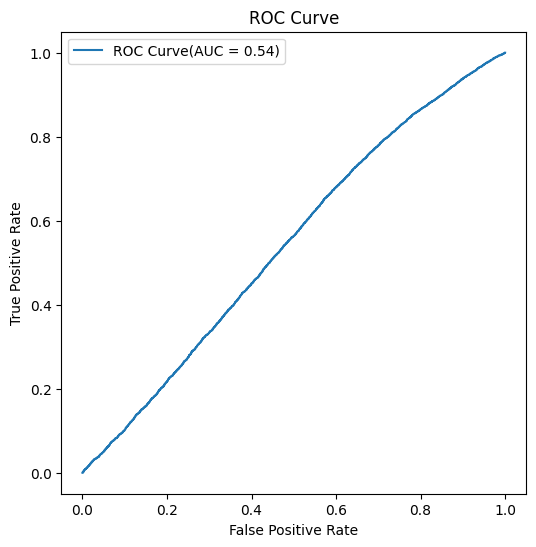

In [93]:
ROC_AUC_score = roc_auc_score(y_test,y_predict)
fpr,tpr,threshold = roc_curve(y_test,y_predict_proba[:,1])

#Plot receiver operating characteristic curve
plt.figure(figsize = (6,6))
plt.plot(fpr,tpr,label = f'ROC Curve(AUC = {ROC_AUC_score:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

<h4>ROC AUC Score of 0.54 indicates that the base Logistic Regression having least predicive power, almost similar to Random Guessing</h4>

<h2>Findings: </h2>
<h5>The base logistic regression having the accuracy 0.54199.   </h5>
<h5>For both test data and train data, the performance is poor. So this model might be a too simple model for the data set. It can be underfit.  
</h5>
<h5 style="color:skyblue">Try to increase the value of C in HPT</h5>

<u><h3>Hyper Parameter Tuning for LogisticRegression</h3> </u>

In [94]:
#Define hyper parameters 
param_distribution = {
    'C': uniform(1,10),
    'solver':['liblinear', 'lbfgs','saga'],
    'penalty':['l2','l1']
}

#Reandomized search
rand_search = RandomizedSearchCV(log_model, param_distributions = param_distribution, n_iter = 10, cv = 5,scoring = 'accuracy', n_jobs = -1,random_state = 42)
rand_search.fit(x_train,y_train)

RandomizedSearchCV(cv=5, estimator=LogisticRegression(random_state=42),
                   n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7bbb4a1a6a70>,
                                        'penalty': ['l2', 'l1'],
                                        'solver': ['liblinear', 'lbfgs',
                                                   'saga']},
                   random_state=42, scoring='accuracy')

In [95]:
print("Hyperparameter combinations tested are: ")
print(rand_search.cv_results_['params'])

Hyperparameter combinations tested are: 
[{'C': 4.745401188473625, 'penalty': 'l2', 'solver': 'saga'}, {'C': 8.31993941811405, 'penalty': 'l2', 'solver': 'liblinear'}, {'C': 2.560186404424365, 'penalty': 'l2', 'solver': 'saga'}, {'C': 1.5808361216819946, 'penalty': 'l1', 'solver': 'liblinear'}, {'C': 7.011150117432088, 'penalty': 'l1', 'solver': 'saga'}, {'C': 1.2058449429580245, 'penalty': 'l1', 'solver': 'lbfgs'}, {'C': 3.1233911067827616, 'penalty': 'l1', 'solver': 'liblinear'}, {'C': 7.1748150962771655, 'penalty': 'l1', 'solver': 'lbfgs'}, {'C': 1.070663052197174, 'penalty': 'l2', 'solver': 'liblinear'}, {'C': 6.2477466025838915, 'penalty': 'l2', 'solver': 'lbfgs'}]


In [98]:
best_log_parameters = rand_search.best_params_
print("Best Hyperparameters are:")
print(best_log_parameters)
print("\n")
best_log_model = rand_search.best_estimator_
print("Best model is:")
print(best_log_model)
print("\n")
print(f"Accuracy with the best model:{best_log_model.score(x_train,y_train)}")

Best Hyperparameters are:
{'C': 1.070663052197174, 'penalty': 'l2', 'solver': 'liblinear'}


Best model is:
LogisticRegression(C=1.070663052197174, random_state=42, solver='liblinear')


Accuracy with the best model:0.5949191165422948


<h3>Best Logistic Regression Model</h3>

In [99]:
best_log_model = LogisticRegression(C=10.960790485618617, penalty='l1', solver='liblinear')
best_log_model.fit(x_train,y_train)

LogisticRegression(C=10.960790485618617, penalty='l1', solver='liblinear')

<h2>Findings: </h2>
<h5>The logistic regression after HPT got an accuracy of 594405.<span style="color:green">(↑)</span></h5>
<h5 style="color:skyblue">Next try - Update it with SGDClassifier with log_loss</h5>

In [100]:
def log_best_model(x_train,y_train,x_test,y_test):
    log = LogisticRegression(C=10.960790485618617, penalty='l1', solver='liblinear',random_state=42)
    log.fit(x_train,y_train)
    y_predict = log.predict(x_test)
    accuracy = log.score(x_train,y_train)
    print(f"Accuracy with the best model:{accuracy}")
    print("\n\n")
    return y_predict,accuracy

<h3>SGDClassifier</h3>
<h4> • Updates weights iteratively</h4>
<h4> • Base Model with default params: loss - hinge, penalty - l2, alpha = 0.0001</h4>


In [101]:
sgd_model = SGDClassifier(random_state = 42)
sgd_model.fit(x_train,y_train)

SGDClassifier(random_state=42)

In [102]:
print("Result")
print("________")
y_predict = sgd_model.predict(x_test)
print(y_predict)
print("\n")
print(f"Accuracy For Base SGDClassifier Model")
print(sgd_model.score(x_test,y_test))

Result
________
[1 1 1 ... 1 1 1]


Accuracy For Base SGDClassifier Model
0.51089297340612


In [103]:
sgd_model = SGDClassifier(loss = 'log_loss',random_state = 42)
sgd_model.fit(x_train,y_train)

SGDClassifier(loss='log_loss', random_state=42)

In [104]:
print("Result")
print("________")
y_predict = sgd_model.predict(x_test)
print(y_predict)
print("\n")
print(f"Accuracy For SGDClassifier Model with log_loss as its loss function")
print(sgd_model.score(x_test,y_test))

Result
________
[0 0 0 ... 0 0 0]


Accuracy For SGDClassifier Model with log_loss as its loss function
0.49341413331997797


In [105]:
sgd_class_report = classification_report(y_test,y_predict,target_names=["Class 0", "Class 1"])
print("Classification report for SGD Classifier is:")
print("\n")
print(sgd_class_report)

Classification report for SGD Classifier is:


              precision    recall  f1-score   support

     Class 0       0.49      1.00      0.66      9852
     Class 1       0.50      0.00      0.00     10115

    accuracy                           0.49     19967
   macro avg       0.50      0.50      0.33     19967
weighted avg       0.50      0.49      0.33     19967



<h2>Findings: </h2>
<h5>Accuracy of the SGDClassifier with log loss: 0.4934 <span style="color:red">(↓)</span></h5>
<h5>Accuracy of the SGDClassifier with default params: 0.5108 <span style="color:red">(↓)</span></h5>
<h5 style="color:skyblue">Logistic Regression Perform well on Linear Model </h5>

<h2>Confusion Matrix for Logistic Regression</h2>

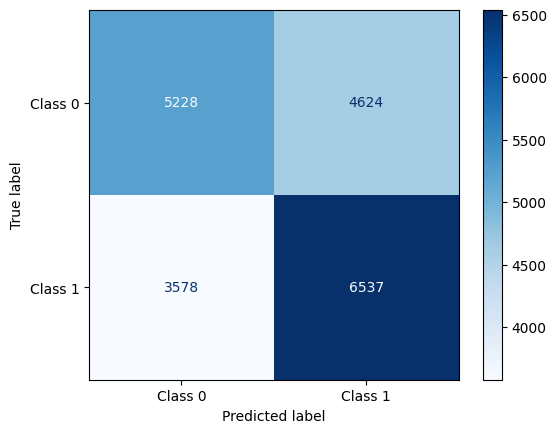

In [106]:
y_predict = best_log_model.predict(x_test)

#Confusion Matrix
con_matrix = confusion_matrix(y_test,y_predict)

#Disply Confusion Matrix
cm = ConfusionMatrixDisplay(con_matrix, display_labels = ["Class 0", "Class 1"])
cm.plot(cmap="Blues")
plt.show()

In [107]:
log_class_report = classification_report(y_test,y_predict,target_names=["Class 0", "Class 1"])
print("Classification report for logistic regression is:")
print("\n")
print(log_class_report)

Classification report for logistic regression is:


              precision    recall  f1-score   support

     Class 0       0.59      0.53      0.56      9852
     Class 1       0.59      0.65      0.61     10115

    accuracy                           0.59     19967
   macro avg       0.59      0.59      0.59     19967
weighted avg       0.59      0.59      0.59     19967



<h3 Next: style="color:skyblue">Feature Selection for Logistic Regression </h3>

<h4>1. Filter Method - SelectKBest Features </h4>

In [347]:
#Defining 
selector = SelectKBest(f_classif,k=40)
#creating new data set 
selected_x_train = selector.fit_transform(x_train,y_train)
selected_x_test = selector.transform(x_test)

In [348]:
#identify the feature is selected or not
selected_or_not = selector.get_support()

#selected feature list
selected_features = x_train.columns[selected_or_not].tolist()

print("Selected features are:")
print("\n")
print(selected_features)

Selected features are:


['EngineVersion', 'AppVersion', 'SignatureVersion', 'Processor', 'OsPlatformSubRelease', 'OSBuildLab', 'SKUEditionName', 'PrimaryDiskType', 'ChassisType', 'PowerPlatformRole', 'NumericOSVersion', 'OSArchitecture', 'OSBranch', 'OSEdition', 'OSSkuFriendlyName', 'OSInstallType', 'AutoUpdateOptionsName', 'LicenseActivationChannel', 'DateAS', 'DateOS', 'AntivirusConfigID', 'NumAntivirusProductsInstalled', 'LocaleEnglishNameID', 'OSBuildNumber', 'OSProductSuite', 'IEVersionID', 'OEMNameID', 'ProcessorCoreCount', 'ProcessorModelID', 'PrimaryDiskCapacityMB', 'SystemVolumeCapacityMB', 'TotalPhysicalRAMMB', 'PrimaryDisplayDiagonalInches', 'PrimaryDisplayResolutionHorizontal', 'PrimaryDisplayResolutionVertical', 'InternalBatteryNumberOfCharges', 'OSBuildRevisionOnly', 'FirmwareManufacturerID', 'IsGamer', 'RegionIdentifier']


In [350]:
feature_score = pd.DataFrame({'Features':x_train.columns,'Feature Score': selector.scores_}).sort_values(by="Feature Score",ascending=False).iloc[:41,:].reset_index(drop=True)
feature_score

,Features,Feature Score
0,NumAntivirusProductsInstalled,1930.574955
1,AntivirusConfigID,918.841603
2,TotalPhysicalRAMMB,547.034053
3,Processor,419.736593
4,OSArchitecture,410.292391
5,IsGamer,313.808515
6,ProcessorCoreCount,306.847352
7,PrimaryDisplayDiagonalInches,283.817785
8,EngineVersion,261.239562
9,SignatureVersion,200.715443


In [351]:
y_predict,accuracy = log_best_model(selected_x_train,y_train,selected_x_test,y_test)

Accuracy with the best model:0.5939299844743827





<h2>Findings: </h2>
<h5>Accuracy of hpt logistic regression model with feature selection of 40 features is 0.5939<span style="color:red">(↓)</span></h5>

<h4>2. Diamensionality Reduction - PCA </h4>

In [108]:
#keep top 30 principal components
pca = PCA(n_components = 5)
pca_x_train = pca.fit_transform(x_train)
pca_x_test = pca.transform(x_test)

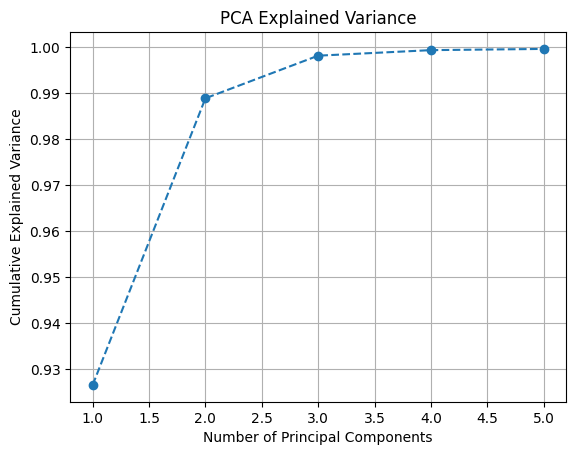

In [109]:
#Explained variance
explained_variance = np.cumsum(pca.explained_variance_ratio_)

#Plot explained variance
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid()
plt.show()

<h4>5 components explained almost complete variance, So most of useful data is retained</h4>

In [110]:
component_matrix = pca.components_
component_matrix[0,:]

array([-1.55048123e-07, -3.73168134e-03, -2.14336989e-03, -7.08663581e-01,
        1.70959951e-06,  1.70279931e-05,  3.53520837e-06, -1.18373509e-04,
       -6.72544663e-03, -4.47133358e-05,  1.80788256e-04, -6.14929091e-08,
       -4.24399811e-05,  3.75000108e-04,  5.85292259e-05, -1.16163998e-02,
        3.38854018e-05, -1.78635290e-04, -1.73450179e-04, -1.95201043e-04,
        1.42140953e-04,  2.65932989e-04,  5.06752041e-06,  1.35963933e-05,
       -1.78384950e-05, -7.05366837e-01, -7.37936512e-03, -0.00000000e+00,
       -0.00000000e+00,  1.95218068e-05,  2.23338166e-05, -0.00000000e+00,
       -0.00000000e+00, -3.12013617e-06, -2.53309352e-06, -4.57601153e-06,
        2.31614023e-06, -8.42287064e-05,  1.67457800e-05, -0.00000000e+00,
       -0.00000000e+00, -0.00000000e+00, -4.75778912e-05, -0.00000000e+00,
       -0.00000000e+00, -4.17146736e-06, -4.06462263e-06, -2.53865126e-05,
       -0.00000000e+00, -1.11121811e-05,  1.38814070e-06,  3.08848558e-06,
       -0.00000000e+00, -

In [111]:
y_predict,accuracy = log_best_model(pca_x_train,y_train,pca_x_test,y_test)

Accuracy with the best model:0.531001151900636





<h2>Findings: </h2>
<h5>Accuracy of HPT Logistic regression with PCA is 0.5310<span style="color:red">(↓)</span></h5>
<h5>The highest accuracy is from HPT of Logistic regression- Accuracy :594405</h5>

<hr>

<h3 style="text-align:center;" >Tree-Based Models - Ensemble</h3>

<u><h3>Random Forest</h3></u>
<h4> • Bagging</h4>
<h4> • Default params: n_estimators = 100, criterion: gini, min_samples_split:2, min_samples_leaf: 1, max_features: "sqrt"</h4>

In [112]:
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [113]:
y_predict = rf.predict(x_test)
accuracy = rf.score(x_test,y_test)
print(f"Accuracy in base random forest is {accuracy}")

Accuracy in base random forest is 0.6121099814694245


In [114]:
rf.feature_importances_

array([1.01364125e-04, 1.01481497e-02, 1.69566056e-02, 5.57839098e-02,
       4.15266885e-04, 2.23314915e-03, 3.74142783e-04, 6.43300799e-03,
       1.28836759e-02, 4.83766090e-03, 9.02737263e-03, 1.47511975e-05,
       7.60041556e-03, 1.24810195e-02, 5.69982149e-03, 2.52960295e-02,
       2.57894838e-03, 8.35412402e-03, 9.29313603e-03, 8.80536742e-03,
       2.27560038e-02, 1.16531252e-02, 5.22393265e-03, 1.10617126e-02,
       2.85139617e-03, 5.86115721e-02, 2.41638296e-02, 0.00000000e+00,
       0.00000000e+00, 2.28227678e-02, 1.71600159e-02, 0.00000000e+00,
       0.00000000e+00, 4.02653715e-02, 5.30220218e-02, 3.39530630e-02,
       3.42091164e-02, 5.44882787e-03, 3.96690386e-03, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 1.07134744e-02, 0.00000000e+00,
       0.00000000e+00, 2.54753235e-02, 4.76914225e-02, 1.03943432e-02,
       0.00000000e+00, 4.35000487e-02, 2.38306019e-02, 5.22002109e-02,
       0.00000000e+00, 1.83132341e-02, 2.93800705e-02, 1.53628385e-02,
      

In [115]:
#Feature importance
importances = rf.feature_importances_
#sort in ascending order
sorted_idx = np.argsort(importances)[::-1]
print("The 10 most contributed feature to model predictions is:")
print("\n")
for i in sorted_idx[:11]:
    print(f"{train_data.columns[i]}:{importances[i]:.4f}")


The 10 most contributed feature to model predictions is:


IEVersionID:0.0586
SignatureVersion:0.0558
ProcessorModelID:0.0530
OSSkuFriendlyName:0.0522
IsVirtualDevice:0.0502
NumericOSVersion:0.0477
OSBuildRevisionOnly:0.0435
ProcessorManufacturerID:0.0403
PrimaryDiskType:0.0342
PrimaryDiskCapacityMB:0.0340
AutoUpdateOptionsName:0.0294


In [116]:
print("classification report:")
print("\n")
print(classification_report(y_test,y_predict))

classification report:


              precision    recall  f1-score   support

           0       0.61      0.60      0.60      9852
           1       0.62      0.62      0.62     10115

    accuracy                           0.61     19967
   macro avg       0.61      0.61      0.61     19967
weighted avg       0.61      0.61      0.61     19967



<h2>Findings: </h2>
<h5>Class wise performance of class 1 is higher than class 0</h5>
<h5>Accuracy of the data in RandomForest : 0.6121 <span style="color:green">(↓)</span></h5>
<h5 style="color:skyblue">Check with hyperparameter tuning </h5>

<h3>HPT for RandomForest</h3>

In [117]:
param_dist = {
    'n_estimators': [100,200,300],
    'max_depth': [None, 10,12],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

#Perform Random search
random_search = RandomizedSearchCV(rf, param_dist, n_iter=10, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)
random_search.fit(x_train,y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 12],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='accuracy')

In [118]:
print("Best Hyperparametes is:")
print("\n")
random_search.best_params_

Best Hyperparametes is:




{'n_estimators': 100,
 'min_samples_split': 10,
 'min_samples_leaf': 4,
 'max_features': 'log2',
 'max_depth': None}

In [119]:
rf_best_model = random_search.best_estimator_
print(f"Best Model is: {rf_best_model}")

Best Model is: RandomForestClassifier(max_features='log2', min_samples_leaf=4,
                       min_samples_split=10, random_state=42)


In [120]:
best_model_accuracy = rf_best_model.score(x_test,y_test)
print(f"Accuracy in random forest with best model: {best_model_accuracy}")

Accuracy in random forest with best model: 0.6147643611959733


<h3>Best Random Forest Model</h3>

In [121]:
best_rf_model = RandomForestClassifier(max_features='log2', min_samples_leaf=4,
                       min_samples_split=10, random_state=42)

In [122]:
rf_class_report = classification_report(y_test,y_predict,target_names=["Class 0", "Class 1"])
print("Classification report for random forest is:")
print("\n")
print(rf_class_report)

Classification report for random forest is:


              precision    recall  f1-score   support

     Class 0       0.61      0.60      0.60      9852
     Class 1       0.62      0.62      0.62     10115

    accuracy                           0.61     19967
   macro avg       0.61      0.61      0.61     19967
weighted avg       0.61      0.61      0.61     19967



<h3>Findings:</h3>
<h4> * With default parameters the accuracy is: 0.6121</h4>
<h4> * With HPT random forest model, the accuracy is: <span style="color:green">0.6147</span></h4>

<u><h3>XGBoost</h3></u>
<h4> • Boosting</h4>
<h4> • Default params: n_estimators = 100,booster='gbtree',learning_rate=0.1 ,max_depth=6, subsample=1, colsample_bytree=1,reg_alpha=0 ,reg_lambda=1,gamma=0</h4>

In [123]:
xgb = XGBClassifier(random_forest=42)
xgb.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_forest=42, ...)

In [124]:
y_predict = xgb.predict(x_test)
accuracy = xgb.score(x_test,y_test)
print(f"Accuracy in base random forest is {accuracy}")

Accuracy in base random forest is 0.617719236740622


<h3>Findings:</h3>
<h4>Accuracy of xgb model is 0.6177 - Highest accuracy till now</h4>

<h3>HPT in XGBoost</h3>

In [125]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# Define XGBoost model
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Define hyperparameter search space
param_dist = {
    'n_estimators': [500, 700],  
    'max_depth': [9, 12],  
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.5,0.6],
    'colsample_bytree': [0.5,0.6],
    'min_child_weight': [2, 3, 4]
}

# Perform Randomized Search (faster than GridSearch)
random_search = RandomizedSearchCV(
    xgb_model, param_distributions=param_dist,
    n_iter=20, cv=5, scoring='accuracy',
    n_jobs= -1, random_state=42
)
random_search.fit(x_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None,
                                           random_state=42, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.5, 0.6],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [9, 12],
                                        'min_child_weight': [2, 3, 4],
                                        'n_estimators': [500, 700],
                                        'subsample': [0.5, 0.6]},
                   random_state=42, scoring='accuracy')

In [126]:
print("Best Hyperparametes are:")
print("\n")
random_search.best_params_

Best Hyperparametes are:




{'subsample': 0.5,
 'n_estimators': 700,
 'min_child_weight': 4,
 'max_depth': 9,
 'learning_rate': 0.01,
 'colsample_bytree': 0.6}

In [127]:
xgb_best_model = random_search.best_estimator_
print(f"Best Model is: {xgb_best_model}")

Best Model is: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
              max_leaves=None, min_child_weight=4, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=700,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)


In [128]:
best_model_accuracy = xgb_best_model.score(x_test,y_test)
print(f"Accuracy in random forest with best model: {best_model_accuracy}")

Accuracy in random forest with best model: 0.6248810537386688


In [129]:
y_predict = xgb_best_model.predict(x_test)

<h3>Best XGBoost Model</h3>

In [130]:
#Define XGBoost model
xgb_best_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss',subsample= 0.6,n_estimators= 700,min_child_weight = 3,max_depth = 12,learning_rate = 0.01,colsample_bytree = 0.5)
xgb_best_model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=12,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=700,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [131]:
y_predict = xgb_best_model.predict(x_test)

In [132]:
xgb_best_model.score(x_test,y_test)

0.6274853508288676

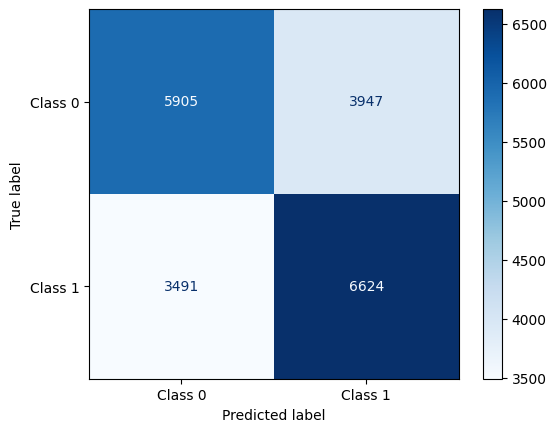

In [133]:
#Confusion Matrix
con_matrix = confusion_matrix(y_test,y_predict)

#Disply Confusion Matrix
cm = ConfusionMatrixDisplay(con_matrix, display_labels = ["Class 0", "Class 1"])
cm.plot(cmap="Blues")
plt.show()

In [134]:
xgb_class_report = classification_report(y_test,y_predict,target_names=["Class 0", "Class 1"])
print("Classification report for random forest is:")
print("\n")
print(xgb_class_report)

Classification report for random forest is:


              precision    recall  f1-score   support

     Class 0       0.63      0.60      0.61      9852
     Class 1       0.63      0.65      0.64     10115

    accuracy                           0.63     19967
   macro avg       0.63      0.63      0.63     19967
weighted avg       0.63      0.63      0.63     19967



<hr>

<h2>Comparison accuracy Logistic Regression, SGD Classifier, Random Forest, XGBoost</h2>

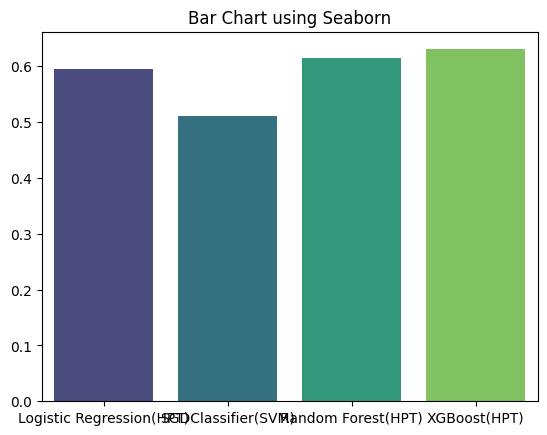

In [135]:
categories = ['Logistic Regression(HPT)','SGDClassifier(SVM)','Random Forest(HPT)','XGBoost(HPT)']
accuracy = [0.594,0.511,0.615,0.630]

sns.barplot(x=categories, y=accuracy, palette='viridis')
plt.title('Bar Chart using Seaborn')
plt.show()

<u><h2>Findings in train data:</h2></u>
<h3>SGDClassifier and Logistic Regression are performing well with outlier capped data.</h3>
<h3>Random forest and XGBoost are perform well without capped outlier data</h3>
<h3>Logistic Regression </h3>
<h4>Max Accuracy - The highest accuracy is from HPT :594405</h4>
<h3>SGDClassifier </h3>
<h4>Max. Accuracy - Default params - 0.5108</h4>
<h3>RandomForest</h3>
<h4>Max Accuracy - HPT - 0.6147</h4>
<h3>Model-XGBoost</h3>
<h4>- With feature engineering except date conversion: 0.629087 <span style="color:green">(Best in train_data)</span></h4> 
<h4>- Caping outliers: With feature engineering except date conversion: 0.62745 <span style="color:red">(↓)</span></h4> 

<u><h2 style="text-align:center;" >For Submission</h2></u>

In [136]:
# # Define XGBoost model
# xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss',subsample= 0.6,n_estimators= 700,min_child_weight = 3,max_depth = 12,learning_rate = 0.01,colsample_bytree = 0.5)
# xgb_model.fit(preprocessed_train_data_df, train_data['target'])

In [137]:
# y_pred = xgb_model.predict(preprocessed_test_data_df)

In [138]:
# submission=pd.DataFrame({'id':range(0,test_data.shape[0]),'target':y_pred})
# submission.to_csv('submission.csv',index=False)

<h2>Overall Findings Till Now</h2>
<h4>-Only droping the single class features are improving the score in both train data and test data</h4>
<h4>- Converting/Removing the Date column(DateAS, DateOS) are reducing the score in both train data and test data</h4>
<h4>- Droping high cardinality column - 'MachineID',Converting unknown to null and droping one of the high correlated column are reducing the test score but improving train score - Overfit</h4>